<a href="https://colab.research.google.com/github/liscano2/practica/blob/main/practicar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import numpy as np
calificaciones = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
 ])
print(calificaciones)
print(calificaciones.shape)
print(calificaciones.ndim)
print(calificaciones.size)
print(calificaciones.dtype)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
(3, 3)
2
9
int64


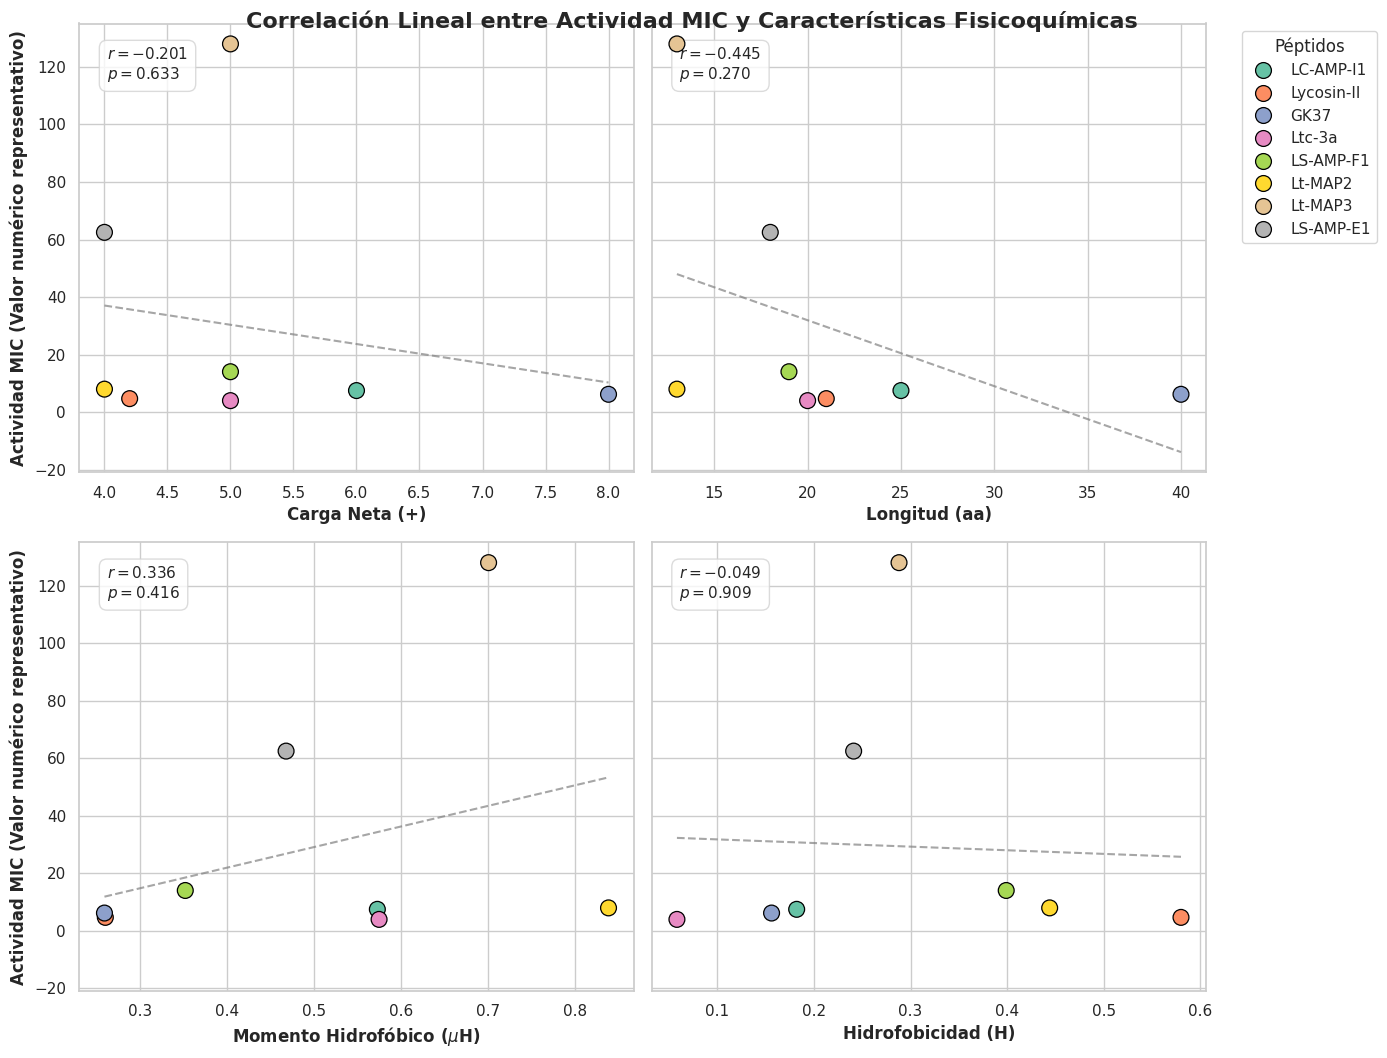

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# Configurar el estilo visual de seaborn
sns.set_theme(style="whitegrid")

# 1. Preparación de los datos a partir de la tabla proporcionada
data = {
    'Peptido': ['LC-AMP-I1', 'Lycosin-II', 'GK37', 'Ltc-3a', 'LS-AMP-F1', 'Lt-MAP2', 'Lt-MAP3', 'LS-AMP-E1'],
    'HADDOCK_Score': [-103.2, -94.5, -93.3, -84.0, -69.7, -62.6, -57.6, -56.3],
    # Valores numéricos de MIC representativos (puntos medios para el cálculo de correlación)
    'MIC_num': [7.5, 4.7, 6.209, 4.0, 14.05, 8.0, 128.0, 62.5],
    'Carga_neta': [6.0, 4.2, 8.0, 5.0, 5.0, 4.0, 5.0, 4.0],
    'Longitud': [25, 21, 40, 20, 19, 13, 13, 18],
    'uH': [0.573, 0.260, 0.259, 0.575, 0.352, 0.839, 0.701, 0.468],
    'Hidrofobicidad': [0.182, 0.580, 0.156, 0.058, 0.399, 0.444, 0.288, 0.241]
}

df = pd.DataFrame(data)

# Exportar el DataFrame a CSV para mantener un registro de los datos transformados
df.to_csv('datos_peptidos_correlacion.csv', index=False)

# 2. Configurar la matriz de gráficos (2x2 subplots) sin usar .figure()
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey=True)
axes = axes.flatten()

# Definición de las variables fisicoquímicas para el eje X
properties = [
    ('Carga_neta', 'Carga Neta (+)'),
    ('Longitud', 'Longitud (aa)'),
    ('uH', 'Momento Hidrofóbico ($\\mu$H)'),
    ('Hidrofobicidad', 'Hidrofobicidad (H)')
]

# Definir una paleta de colores fija para que cada péptido tenga un color único y consistente
palette = sns.color_palette("Set2", len(df['Peptido']))
peptide_colors = dict(zip(df['Peptido'], palette))

# 3. Construcción de los subplots
for i, (col, label) in enumerate(properties):
    ax = axes[i]

    # Gráfico de dispersión (Scatter plot) con colores asignados por péptido
    sns.scatterplot(
        data=df,
        x=col,
        y='MIC_num',
        hue='Peptido',
        palette=peptide_colors,
        s=130,
        ax=ax,
        edgecolor='black',
        zorder=5
    )

    # Calcular el coeficiente de correlación lineal de Pearson (r) y el valor p
    r_val, p_val = pearsonr(df[col], df['MIC_num'])

    # Calcular y trazar la línea de tendencia lineal (regresión)
    m, b = np.polyfit(df[col], df['MIC_num'], 1)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, m * x_range + b, color='gray', linestyle='--', alpha=0.7, zorder=1)

    # Configuración de etiquetas de los ejes
    ax.set_xlabel(label, fontsize=12, fontweight='bold')
    if i % 2 == 0:
        ax.set_ylabel('Actividad MIC (Valor numérico representativo)', fontsize=12, fontweight='bold')
    else:
        ax.set_ylabel('')

    # Recuadro de texto con la información estadística del coeficiente de correlación $r$
    ax.text(
        0.05, 0.95, f'$r = {r_val:.3f}$\n$p = {p_val:.3f}$',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray')
    )

    # Organizar las leyendas para evitar duplicación repetitiva
    if i != 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='Péptidos', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Título principal de la infografía
plt.suptitle('Correlación Lineal entre Actividad MIC y Características Fisicoquímicas', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout()

# 4. Guardar el gráfico resultante en alta resolución
plt.savefig('correlacion_mic_propiedades.png', dpi=300, bbox_inches='tight')

In [ ]:
import pandas as pd
import numpy as np

# Creamos datos sintéticos con problemas de calidad
data = {
    'ID_Paciente': range(1, 11),
    'Edad': [45, np.nan, 30, 72, 25, 50, np.nan, 19, 34, 55], # 20% faltante
    'Sexo': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', np.nan, 'F'], # 10% faltante
    'Glucosa_Basal': [90, 110, 85, np.nan, 95, 105, 100, 92, 103, np.nan], # 20% faltante
    'Biomarcador_Experimental': [1.2, np.nan, np.nan, 0.8, np.nan, 1.5, np.nan, np.nan, 1.1, np.nan], # 60% faltante
    'Estado_Egreso': ['Vivo', 'Fallecido', 'Vivo', 'Fallecido', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Fallecido']
}

df = pd.DataFrame(data)
print("Dataset cargado con éxito.")

Dataset cargado con éxito.


In [ ]:
# Buscar palabra dentro de una columna con str.contains
df[df['Estado_Egreso'].str.contains("Vivo")]

,ID_Paciente,Edad,Sexo,Glucosa_Basal,Biomarcador_Experimental,Estado_Egreso
0,1,45.0,M,90.0,1.2,Vivo
2,3,30.0,M,85.0,NaN,Vivo
4,5,25.0,M,95.0,NaN,Vivo
5,6,50.0,F,105.0,1.5,Vivo
6,7,NaN,M,100.0,NaN,Vivo
7,8,19.0,F,92.0,NaN,Vivo
8,9,34.0,NaN,103.0,1.1,Vivo


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Paciente               10 non-null     int64  
 1   Edad                      8 non-null      float64
 2   Sexo                      9 non-null      object 
 3   Glucosa_Basal             8 non-null      float64
 4   Biomarcador_Experimental  4 non-null      float64
 5   Estado_Egreso             10 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 612.0+ bytes


In [ ]:
df.describe(include = 'all')

,ID_Paciente,Edad,Sexo,Glucosa_Basal,Biomarcador_Experimental,Estado_Egreso
count,10.00000,8.000000,9,8.000000,4.000000,10
unique,NaN,NaN,2,NaN,NaN,2
top,NaN,NaN,F,NaN,NaN,Vivo
freq,NaN,NaN,5,NaN,NaN,7
mean,5.50000,41.250000,NaN,97.500000,1.150000,NaN
std,3.02765,17.580427,NaN,8.434623,0.288675,NaN
min,1.00000,19.000000,NaN,85.000000,0.800000,NaN
25%,3.25000,28.750000,NaN,91.500000,1.025000,NaN
50%,5.50000,39.500000,NaN,97.500000,1.150000,NaN
75%,7.75000,51.250000,NaN,103.500000,1.275000,NaN


In [ ]:
%load_ext google.colab.data_table
df

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


,ID_Paciente,Edad,Sexo,Glucosa_Basal,Biomarcador_Experimental,Estado_Egreso
0,1,45.0,M,90.0,1.2,Vivo
1,2,NaN,F,110.0,NaN,Fallecido
2,3,30.0,M,85.0,NaN,Vivo
3,4,72.0,F,NaN,0.8,Fallecido
4,5,25.0,M,95.0,NaN,Vivo
5,6,50.0,F,105.0,1.5,Vivo
6,7,NaN,M,100.0,NaN,Vivo
7,8,19.0,F,92.0,NaN,Vivo
8,9,34.0,NaN,103.0,1.1,Vivo
9,10,55.0,F,NaN,NaN,Fallecido


In [ ]:
%unload_ext google.colab.data_table

The google.colab.data_table extension is not loaded.


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1K3k-pPoOnTlgotSmTC49V20q80EaAN9EAKR1bFy9-oI/edit#gid=0


In [ ]:
df.isna()

,ID_Paciente,Edad,Sexo,Glucosa_Basal,Biomarcador_Experimental,Estado_Egreso
0,False,False,False,False,False,False
1,False,True,False,False,True,False
2,False,False,False,False,True,False
3,False,False,False,True,False,False
4,False,False,False,False,True,False
5,False,False,False,False,False,False
6,False,True,False,False,True,False
7,False,False,False,False,True,False
8,False,False,True,False,False,False
9,False,False,False,True,True,False


In [ ]:
df.isna().sum()

,0
ID_Paciente,0
Edad,2
Sexo,1
Glucosa_Basal,2
Biomarcador_Experimental,6
Estado_Egreso,0


In [ ]:
df.isnull().sum()

,0
ID_Paciente,0
Edad,2
Sexo,1
Glucosa_Basal,2
Biomarcador_Experimental,6
Estado_Egreso,0


In [ ]:
Porcentaje_na = (df.isnull().sum() / len(df)) * 100
print(Porcentaje_na)

ID_Paciente                  0.0
Edad                        20.0
Sexo                        10.0
Glucosa_Basal               20.0
Biomarcador_Experimental    60.0
Estado_Egreso                0.0
dtype: float64


In [ ]:
# Eliminamos la columna por exceso de ausencia >40%
df_limpio = df.drop(columns=['Biomarcador_Experimental'])
print(df)
print(df_limpio)

   ID_Paciente  Edad Sexo  Glucosa_Basal  Biomarcador_Experimental  \
0            1  45.0    M           90.0                       1.2   
1            2   NaN    F          110.0                       NaN   
2            3  30.0    M           85.0                       NaN   
3            4  72.0    F            NaN                       0.8   
4            5  25.0    M           95.0                       NaN   
5            6  50.0    F          105.0                       1.5   
6            7   NaN    M          100.0                       NaN   
7            8  19.0    F           92.0                       NaN   
8            9  34.0  NaN          103.0                       1.1   
9           10  55.0    F            NaN                       NaN   

  Estado_Egreso  
0          Vivo  
1     Fallecido  
2          Vivo  
3     Fallecido  
4          Vivo  
5          Vivo  
6          Vivo  
7          Vivo  
8          Vivo  
9     Fallecido  
   ID_Paciente  Edad Sexo  Gluc

In [ ]:
# Imputación de variables numéricas con la mediana (5-40%)
df_limpio['Edad'] = df_limpio['Edad'].fillna(df_limpio['Edad'].median())
df_limpio['Glucosa_Basal'] = df_limpio['Glucosa_Basal'].fillna(df_limpio['Glucosa_Basal'].median())

print(df_limpio)

   ID_Paciente  Edad Sexo  Glucosa_Basal Estado_Egreso
0            1  45.0    M           90.0          Vivo
1            2  39.5    F          110.0     Fallecido
2            3  30.0    M           85.0          Vivo
3            4  72.0    F           97.5     Fallecido
4            5  25.0    M           95.0          Vivo
5            6  50.0    F          105.0          Vivo
6            7  39.5    M          100.0          Vivo
7            8  19.0    F           92.0          Vivo
8            9  34.0  NaN          103.0          Vivo
9           10  55.0    F           97.5     Fallecido


In [ ]:
# Eliminamos las filas donde el Sexo sea nulo (<5%)
df_final = df_limpio.dropna(subset=['Sexo'])
print(df_final)

   ID_Paciente  Edad Sexo  Glucosa_Basal Estado_Egreso
0            1  45.0    M           90.0          Vivo
1            2  39.5    F          110.0     Fallecido
2            3  30.0    M           85.0          Vivo
3            4  72.0    F           97.5     Fallecido
4            5  25.0    M           95.0          Vivo
5            6  50.0    F          105.0          Vivo
6            7  39.5    M          100.0          Vivo
7            8  19.0    F           92.0          Vivo
9           10  55.0    F           97.5     Fallecido


In [ ]:
print(f"Dimensiones finales: {df_final.shape}")
print(df_final.isnull().sum())

Dimensiones finales: (9, 5)
ID_Paciente      0
Edad             0
Sexo             0
Glucosa_Basal    0
Estado_Egreso    0
dtype: int64


In [ ]:
# Aplicamos One-Hot Encoding a las columnas categóricas
# Usamos dtype=int para obtener 1 y 0 en lugar de True y False
df_encoded = pd.get_dummies(df, columns=['Sexo', 'Estado_Egreso'], dtype=int)

print(df_encoded)

   ID_Paciente  Edad  Glucosa_Basal  Biomarcador_Experimental  Sexo_F  Sexo_M  \
0            1  45.0           90.0                       1.2       0       1   
1            2   NaN          110.0                       NaN       1       0   
2            3  30.0           85.0                       NaN       0       1   
3            4  72.0            NaN                       0.8       1       0   
4            5  25.0           95.0                       NaN       0       1   
5            6  50.0          105.0                       1.5       1       0   
6            7   NaN          100.0                       NaN       0       1   
7            8  19.0           92.0                       NaN       1       0   
8            9  34.0          103.0                       1.1       0       0   
9           10  55.0            NaN                       NaN       1       0   

   Estado_Egreso_Fallecido  Estado_Egreso_Vivo  
0                        0                   1  
1         

In [ ]:
# Nos quedamos solo con la primera aparición de cada combinación de Sexo y Estado_Egreso
df_unicos_por_grupo = df.drop_duplicates(subset=['Sexo', 'Estado_Egreso'])

print(df_unicos_por_grupo)

   ID_Paciente  Edad Sexo  Glucosa_Basal  Biomarcador_Experimental  \
0            1  45.0    M           90.0                       1.2   
1            2   NaN    F          110.0                       NaN   
5            6  50.0    F          105.0                       1.5   
8            9  34.0  NaN          103.0                       1.1   

  Estado_Egreso  
0          Vivo  
1     Fallecido  
5          Vivo  
8          Vivo  


In [ ]:
# Parte final
print(f'Resultado final: {df_unicos_por_grupo.shape}')

Resultado final: (4, 6)


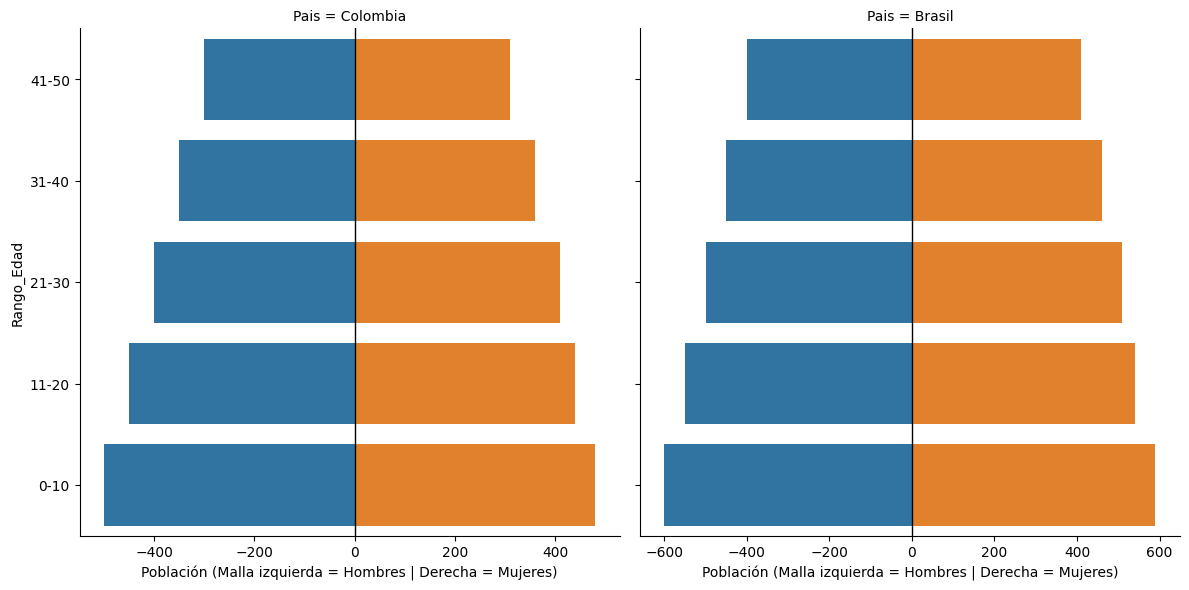

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear datos sintéticos (Formato Largo/Unpivoted)
data = {
    'Pais': ['Colombia']*10 + ['Brasil']*10,
    'Rango_Edad': ['0-10', '11-20', '21-30', '31-40', '41-50']*4,
    'Sexo': ['M', 'M', 'M', 'M', 'M', 'F', 'F', 'F', 'F', 'F']*2,
    'Poblacion': [500, 450, 400, 350, 300, 480, 440, 410, 360, 310,  # Colombia
                  600, 550, 500, 450, 400, 590, 540, 510, 460, 410]   # Brasil
}
df = pd.DataFrame(data)

# 2. El TRUCO: Convertir una categoría en negativa para el espejo
df['Poblacion_Grafico'] = df.apply(lambda x: -x['Poblacion'] if x['Sexo'] == 'M' else x['Poblacion'], axis=1)

# 3. Visualización con FacetGrid (para comparar países)
g = sns.FacetGrid(df, col="Pais", hue="Sexo", sharex=False, height=6)

# Graficar barras
g.map(sns.barplot, "Poblacion_Grafico", "Rango_Edad", order=['41-50', '31-40', '21-30', '11-20', '0-10'])

# Ajustes estéticos
for ax in g.axes.flat:
    ax.axvline(0, color='black', lw=1) # Línea central
    ax.set_xlabel("Población (Malla izquierda = Hombres | Derecha = Mujeres)")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
n = 50
sexo = np.random.choice(['M','F'], n)
Edad = np.random.normal(18,20,n)
altura = np.random.normal(1.6,0.1,n)
peso = np.random.normal(60,10,n)
Clasificacion_IMC = np.random.choice(['Normopeso','Sobrepeso','Obesidad'], n)
Exposicion = np.random.choice(['Activo', 'Inactivo'], n)
Estrato = np.random.choice([1,2,3,4,5], n)
Tipo_colegio = np.random.choice(['Publico','Privado'], n)

df =pd.DataFrame({
    'ID': range(1, n+1),
    'Sexo': sexo,
    'Edad': Edad,
    'Altura': altura,
    'Peso': peso,
    'Clasificacion_IMC': Clasificacion_IMC,
    'Exposicion': Exposicion,
    'Estrato': Estrato,
    'Tipo_colegio': Tipo_colegio
})
print(f"{df.head()}")

   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    M  20.482564  1.591244  61.102438          Obesidad     Activo   
1   2    M  50.335426  1.345131  62.804894         Normopeso     Activo   
2   3    M  27.527888  1.578865  50.361467         Sobrepeso   Inactivo   
3   4    M  11.216816  1.646882  64.842976         Sobrepeso     Activo   
4   5    M  17.063472  1.611308  62.771838         Sobrepeso   Inactivo   

   Estrato Tipo_colegio  
0        3      Privado  
1        5      Privado  
2        3      Privado  
3        4      Privado  
4        2      Publico  


In [ ]:
nivel_actividad = np.random.choice(['Bajo','Moderado','Alto'],n)
df['Nivel_actividad'] = nivel_actividad
print("----El resultado es----")
print(df.head())

----El resultado es----
   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    M  20.482564  1.591244  61.102438          Obesidad     Activo   
1   2    M  50.335426  1.345131  62.804894         Normopeso     Activo   
2   3    M  27.527888  1.578865  50.361467         Sobrepeso   Inactivo   
3   4    M  11.216816  1.646882  64.842976         Sobrepeso     Activo   
4   5    M  17.063472  1.611308  62.771838         Sobrepeso   Inactivo   

   Estrato Tipo_colegio Nivel_actividad  
0        3      Privado            Alto  
1        5      Privado            Bajo  
2        3      Privado        Moderado  
3        4      Privado            Bajo  
4        2      Publico            Bajo  


In [ ]:
df['Exposicion'] = df['Exposicion'].str.upper()
print(df.head())

   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    M  20.482564  1.591244  61.102438          Obesidad     ACTIVO   
1   2    M  50.335426  1.345131  62.804894         Normopeso     ACTIVO   
2   3    M  27.527888  1.578865  50.361467         Sobrepeso   INACTIVO   
3   4    M  11.216816  1.646882  64.842976         Sobrepeso     ACTIVO   
4   5    M  17.063472  1.611308  62.771838         Sobrepeso   INACTIVO   

   Estrato Tipo_colegio Nivel_actividad  
0        3      Privado            Alto  
1        5      Privado            Bajo  
2        3      Privado        Moderado  
3        4      Privado            Bajo  
4        2      Publico            Bajo  


In [ ]:
df.dtypes

,0
ID,int64
Sexo,object
Edad,float64
Altura,float64
Peso,float64
Clasificacion_IMC,object
Exposicion,object
Estrato,int64
Tipo_colegio,object
Nivel_actividad,object


In [ ]:
df['ID'] = df['ID'].astype(str)
df['Edad'] = df['Edad'].astype(int)
df['Clasificacion_IMC'] = df['Clasificacion_IMC'].astype('category')
df['Exposicion'] = df['Exposicion'].astype('category')
df['Estrato'] = df['Estrato'].astype(str)
df['Nivel_actividad'] =df['Nivel_actividad'].astype('category')
df['Tipo_colegio'] = df['Tipo_colegio'].astype('category')
print(df.dtypes)


ID                     object
Sexo                   object
Edad                    int64
Altura                float64
Peso                  float64
Clasificacion_IMC    category
Exposicion           category
Estrato                object
Tipo_colegio         category
Nivel_actividad      category
dtype: object


In [ ]:
df['Tipo_colegio'].value_counts()

,count
Tipo_colegio,
Privado,28
Publico,22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 50 non-null     int64  
 1   Sexo               50 non-null     object 
 2   Edad               50 non-null     float64
 3   Altura             50 non-null     float64
 4   Peso               50 non-null     float64
 5   Clasificacion_IMC  50 non-null     object 
 6   Exposicion         50 non-null     object 
 7   Estrato            50 non-null     int64  
 8   Tipo_colegio       50 non-null     object 
 9   Nivel_actividad    50 non-null     object 
dtypes: float64(3), int64(2), object(5)
memory usage: 4.0+ KB


In [ ]:
media = df['Edad'].mean()
moda = df['Edad'].mode()[0]
mediana =df['Edad'].median()
desviacion = df['Edad'].std()
varianza = df['Edad'].var()
minimo = df['Edad'].min()
maximo = df['Edad'].max()
curtosis = df['Edad'].kurt()
asimetria = df['Edad'].skew()
cuartil25 = df['Edad'].quantile(0.25)
cuartile75 = df['Edad'].quantile(0.75)
IQR = df['Edad'].quantile(0.75) - df['Edad'].quantile(0.25)
print(f"La media es {media}, la moda es {moda}, la mediana es {mediana}, cuya desviacion es {desviacion}, \n el IQR {IQR}, \n la asimetria es {round(asimetria, 3)}" )

La media es 24.74, la moda es -13, la mediana es 23.5, cuya desviacion es 21.53100280137117, 
 el IQR 26.75, 
 la asimetria es 0.085


<Axes: xlabel='Altura', ylabel='Peso'>

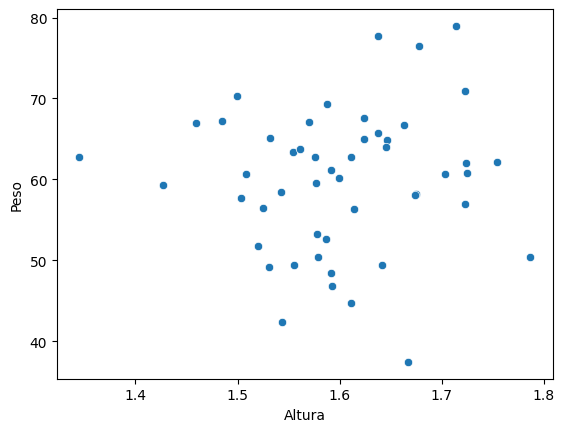

In [ ]:
import seaborn as sns
sns.scatterplot(df,x ='Altura', y ='Peso')

In [ ]:
filtrado = df[(df['Sexo'] == 'M') & (df['Edad'] > 20)]
print(filtrado)

    ID Sexo  Edad    Altura       Peso Clasificacion_IMC Exposicion Estrato  \
1    2    M    50  1.345131  62.804894         Normopeso     ACTIVO       5   
2    3    M    27  1.578865  50.361467         Sobrepeso   INACTIVO       3   
5    6    M    52  1.624362  67.603404         Normopeso   INACTIVO       3   
6    7    M    22  1.714019  78.963055         Sobrepeso   INACTIVO       2   
7    8    M    53  1.724844  60.798182          Obesidad     ACTIVO       4   
9   10    M    31  1.611622  44.767790          Obesidad   INACTIVO       4   
12  13    M    28  1.677936  76.506949         Sobrepeso     ACTIVO       5   
16  17    M    32  1.554716  63.423241          Obesidad   INACTIVO       2   
22  23    M    23  1.786903  50.428622          Obesidad   INACTIVO       5   
27  28    M    72  1.613837  56.304345         Normopeso   INACTIVO       3   
28  29    M    53  1.508020  60.635114         Sobrepeso   INACTIVO       2   
33  34    M    55  1.575999  62.740442         Normo

<Axes: xlabel='Sexo', ylabel='count'>

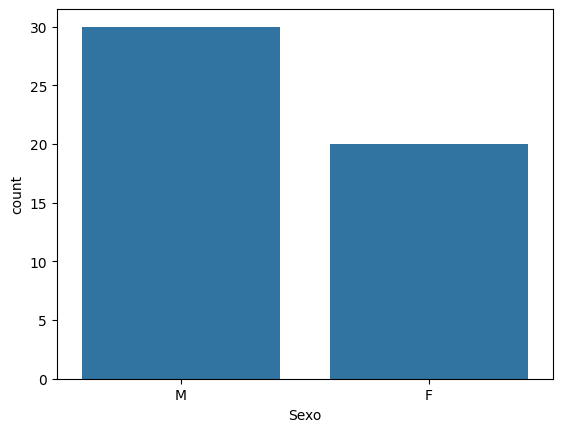

In [ ]:
sexo2 = df['Sexo'].value_counts()
sns.barplot(sexo2)

<Axes: xlabel='Sexo', ylabel='Edad'>

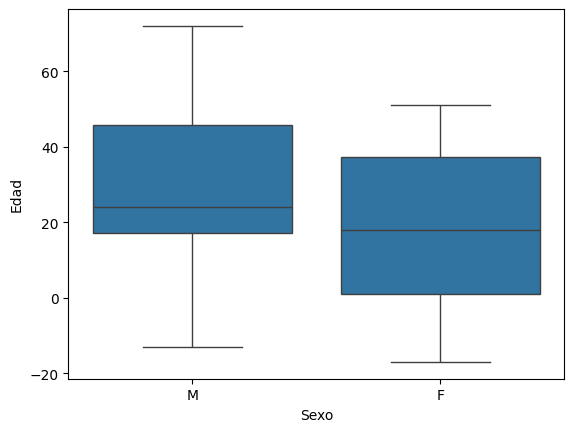

In [ ]:
sns.boxplot(df, x = 'Sexo', y = 'Edad')

<Axes: xlabel='Altura', ylabel='Peso'>

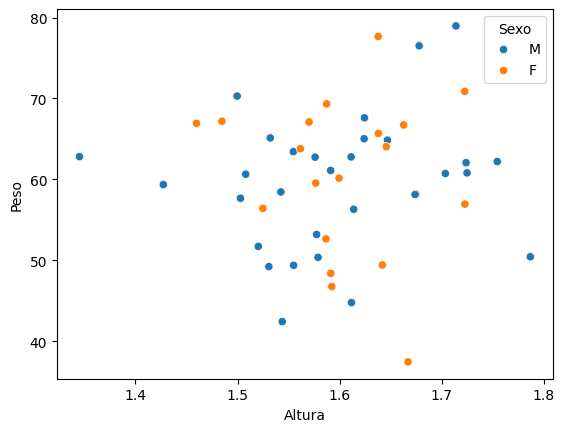

In [ ]:
sns.scatterplot(df, x = 'Altura', y = 'Peso', hue = 'Sexo')

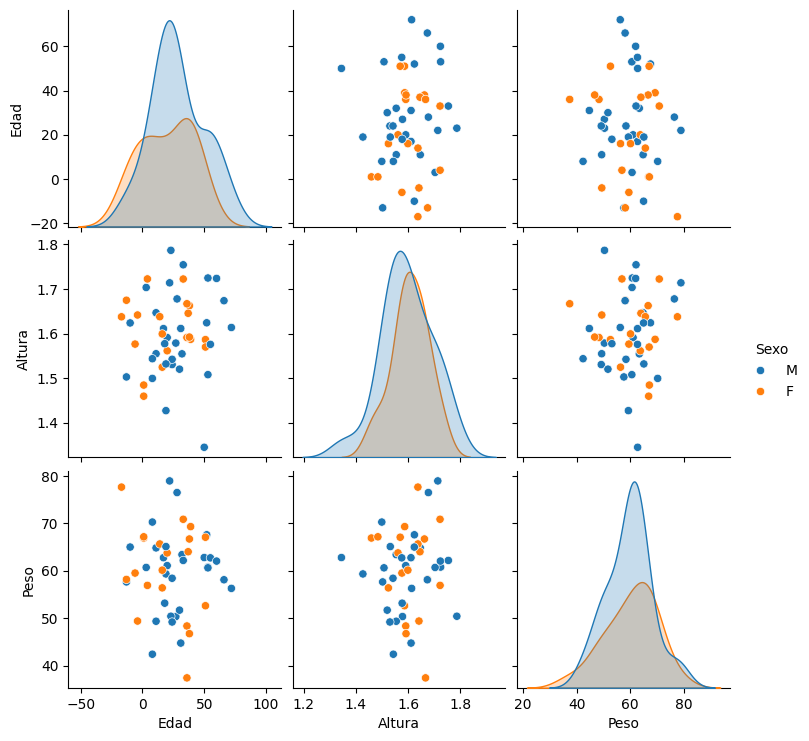

In [ ]:
sns.pairplot(df, hue = 'Sexo')

<Axes: xlabel='Exposicion', ylabel='count'>

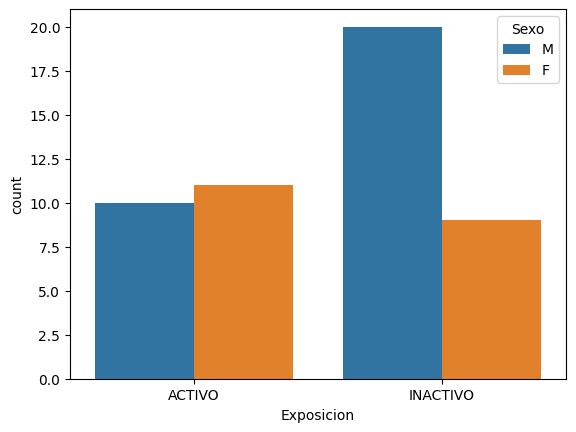

In [ ]:
sns.countplot(df, x = "Exposicion", hue = "Sexo")

<Axes: xlabel='count', ylabel='Estrato'>

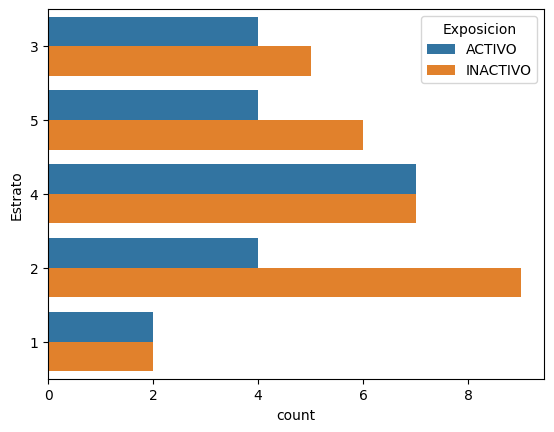

In [ ]:
sns.countplot(df, y = "Estrato", hue = "Exposicion")

<Axes: xlabel='Peso', ylabel='Proportion'>

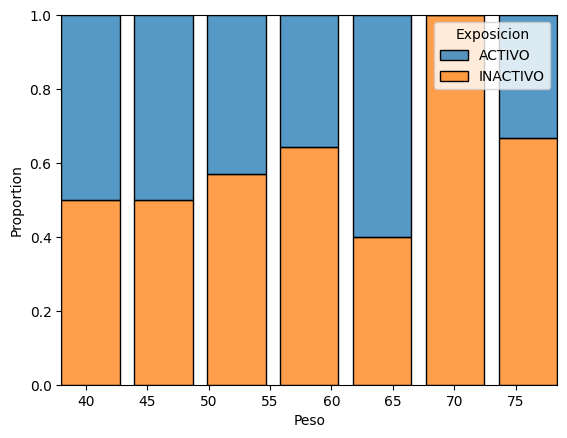

In [ ]:
sns.histplot(df, x = 'Peso',
             hue = 'Exposicion',
             multiple = 'fill',
             stat = "proportion",
             shrink=0.8)


<Axes: xlabel='Altura', ylabel='Peso'>

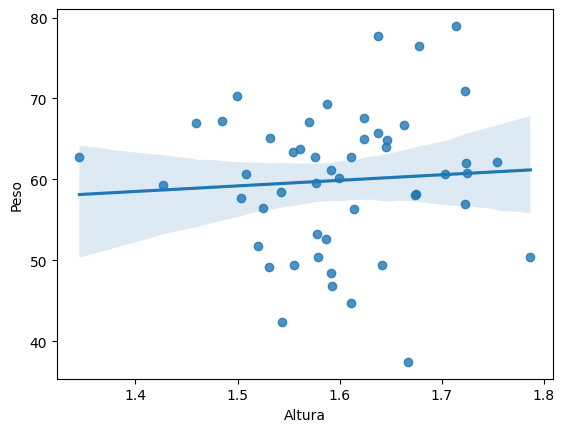

In [ ]:
sns.regplot(df, x = 'Altura', y = 'Peso')

In [ ]:
tabla_contingencia = pd.crosstab(df['Sexo'], df['Exposicion'])
print(tabla_contingencia)

Exposicion  ACTIVO  INACTIVO
Sexo                        
F               11         9
M               10        20


<Axes: xlabel='Exposicion', ylabel='Sexo'>

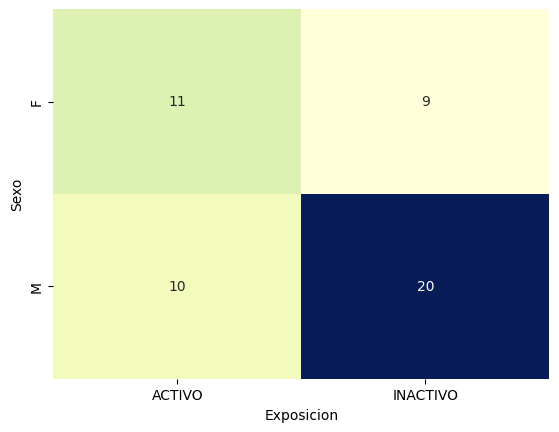

In [ ]:
sns.heatmap(tabla_contingencia, annot=True, cmap='YlGnBu', cbar=False)

In [ ]:
frutas = ['Manzanas','Peras', 'Bananos','Mangos']
for frutas in frutas:
  print(f"enviando invitación a:\n {frutas}")

enviando invitación a:
 Manzanas
enviando invitación a:
 Peras
enviando invitación a:
 Bananos
enviando invitación a:
 Mangos


In [ ]:
suma = 0
for numero in range(1, 101):
  suma += numero
print(suma)

5050


In [ ]:
numeros = [2,5,10,14,24,26,8,9,10,14,19]
for n in numeros:
  if n > 10:
    print(f"{n} es grande")

14 es grande
24 es grande
26 es grande
14 es grande
19 es grande


In [ ]:
tareas = ['Lavar','Cocinar','Comprar']
for i, tarea in enumerate(tareas, start =1):
  print(f"Tarea #{i}: {tarea}")

Tarea #1: Lavar
Tarea #2: Cocinar
Tarea #3: Comprar


In [ ]:
Peso = [80,62,60,70,82]
peso_nuevo =[]
for i in Peso:
  b = i + 1
  peso_nuevo.append(b)
print(f"{peso_nuevo}")


[81, 63, 61, 71, 83]


In [ ]:
contador = 5  # 1. Inicio

while contador > 0:  # 2. Condición
    print(f"Despegue en {contador}...")
    contador = contador - 1  # 3. Actualización (si quitas esto, nunca termina)

print("¡IGNICIÓN! 🚀")

Despegue en 5...
Despegue en 4...
Despegue en 3...
Despegue en 2...
Despegue en 1...
¡IGNICIÓN! 🚀


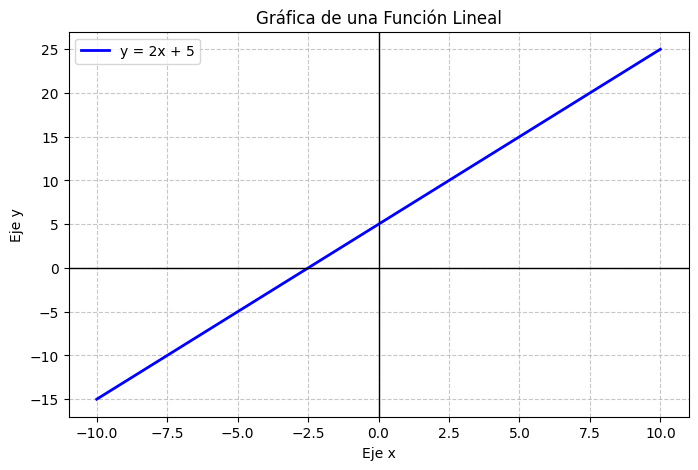

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos la función lineal
def funcion_lineal(x, m, b):
    return m * x + b

# 2. Creamos los datos para el eje x (de -10 a 10, con 100 puntos)
x = np.linspace(-10, 10, 100)

# 3. Definimos nuestros parámetros
pendiente = 2
intercepto = 5

# 4. Calculamos los valores de y
y = funcion_lineal(x, pendiente, intercepto)

# 5. Creamos la gráfica
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'y = {pendiente}x + {intercepto}', color='blue', linewidth=2)

# 6. Estética de la gráfica
plt.axhline(0, color='black', linewidth=1) # Eje X
plt.axvline(0, color='black', linewidth=1) # Eje Y
plt.title('Gráfica de una Función Lineal')
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 7. Mostramos el resultado
plt.show()

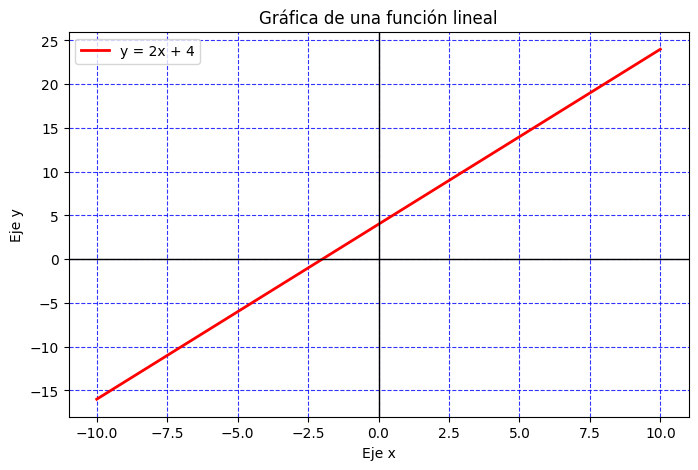

In [ ]:
def funcion_lineal2(x, m, b):
  return m * x + b

x = np.linspace(-10, 10, 100)
pendiente = 2
intercepto = 4
y = funcion_lineal2(x,pendiente, intercepto)

plt.figure(figsize=(8,5))
plt.plot(x,y, label = f'y = {pendiente}x + {intercepto}', color = 'red', linewidth =2)

plt.title('Gráfica de una función lineal')
plt.axhline(0, color = 'black', linewidth = 1)
plt.axvline(0, color = 'black', linewidth = 1)
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid(True, linestyle = '--', alpha = 0.8, color = 'blue')
plt.legend()
plt.show()


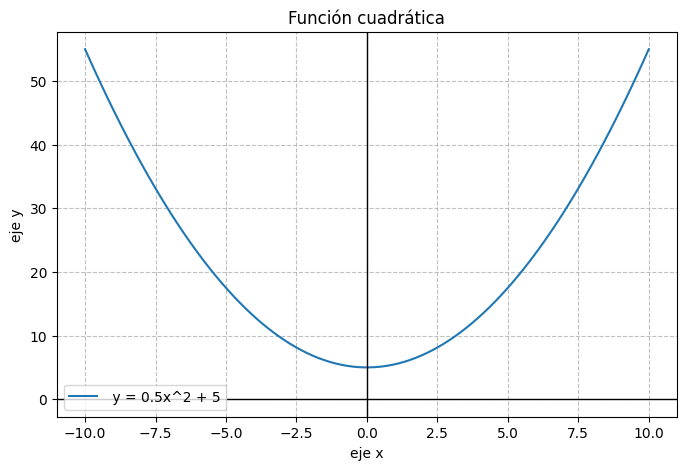

In [ ]:
def cuadratica(x, m, b):
  return m * x**2 + b

x = np.linspace(-10,10,100)
pendiente = 0.5
intercepto = 5
y = cuadratica(x, pendiente, intercepto)

plt.figure(figsize=(8,5))
plt.plot(x,y, label = f' y = {pendiente}x^2 + {intercepto}')

#Estetica
plt.axhline(0, color = 'black', linewidth = 1)
plt.axvline(0, color = 'black', linewidth = 1)
plt.title('Función cuadrática')
plt.xlabel('eje x')
plt.ylabel('eje y')
plt.grid(True, linestyle = '--', alpha = 0.8)
plt.legend()
plt.show()

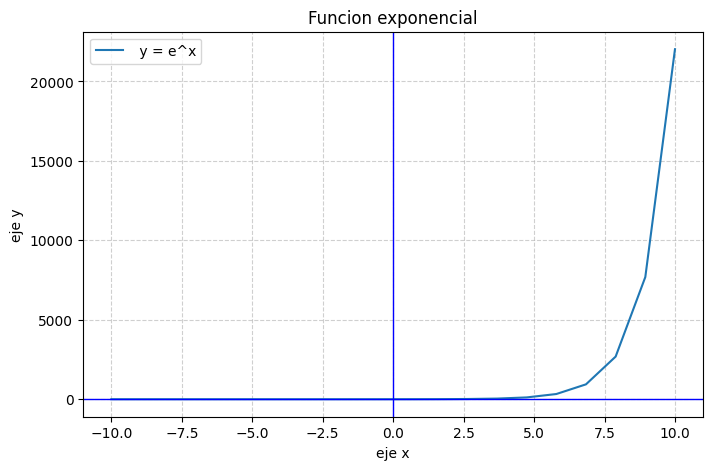

In [ ]:
def exponencial(x):
  return np.exp(x)

x = np.linspace(-10,10,20)
y = exponencial(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label = f' y = e^x')

plt.axhline(0, color = 'blue',  linewidth = 1)
plt.axvline(0, color = 'blue',  linewidth = 1)
plt.title('Funcion exponencial')
plt.xlabel('eje x')
plt.ylabel('eje y')
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend()
plt.show()

/tmp/ipykernel_643/703474419.py:2: RuntimeWarning: invalid value encountered in log10
  return np.log10(x)


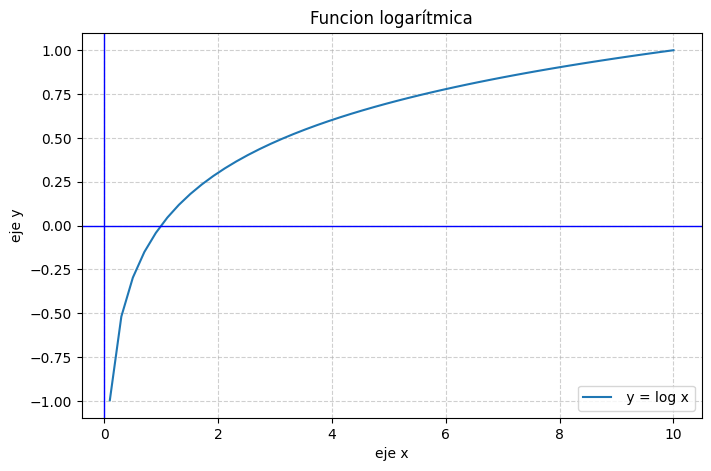

In [ ]:
def logaritmica(x):
  return np.log10(x)

x = np.linspace(-10,10,100)
y = exponencial(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label = f' y = log x')

plt.axhline(0, color = 'blue',  linewidth = 1)
plt.axvline(0, color = 'blue',  linewidth = 1)
plt.title('Funcion logarítmica')
plt.xlabel('eje x')
plt.ylabel('eje y')
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend()
plt.show()

Distancia: 2.83
Punto Medio: (2.0, 5.0)


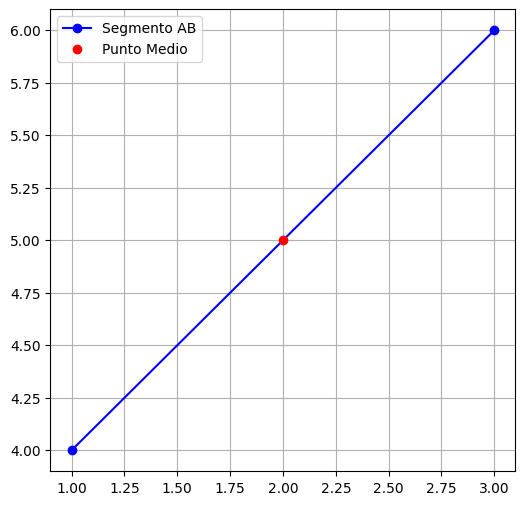

In [ ]:
import math
import matplotlib.pyplot as plt

def geometria_basica(p1, p2):
    # p1 y p2 son tuplas (x, y)
    distancia = math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
    punto_medio = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)

    print(f"Distancia: {distancia:.2f}")
    print(f"Punto Medio: {punto_medio}")

    # Visualización
    plt.figure(figsize=(6,6))
    x_coords = [p1[0], p2[0]]
    y_coords = [p1[1], p2[1]]

    plt.plot(x_coords, y_coords, 'bo-', label='Segmento AB')
    plt.plot(punto_medio[0], punto_medio[1], 'ro', label='Punto Medio')
    plt.grid(True)
    plt.legend()
    plt.show()

# Probemos con el punto A(1, 2) y B(7, 6)
geometria_basica((1, 4), (3, 6))

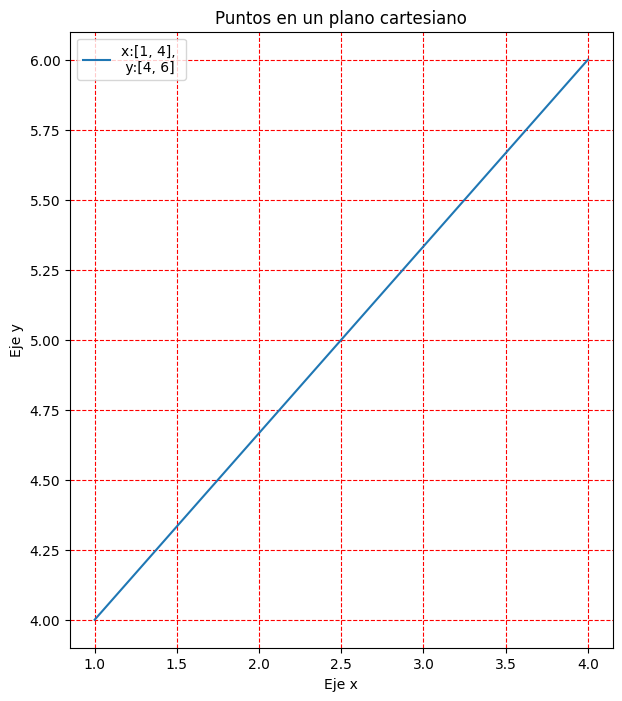

In [ ]:
import matplotlib.pyplot as plt
x_coordenadas = [1,4]
y_coordenadas = [4, 6]

plt.figure(figsize=(7,8))
plt.plot(x_coordenadas, y_coordenadas, label = f'x:{x_coordenadas}, \n y:{y_coordenadas}')

plt.title('Puntos en un plano cartesiano')
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.legend()
plt.grid(True, linestyle = '--', color = 'red')
plt.show()


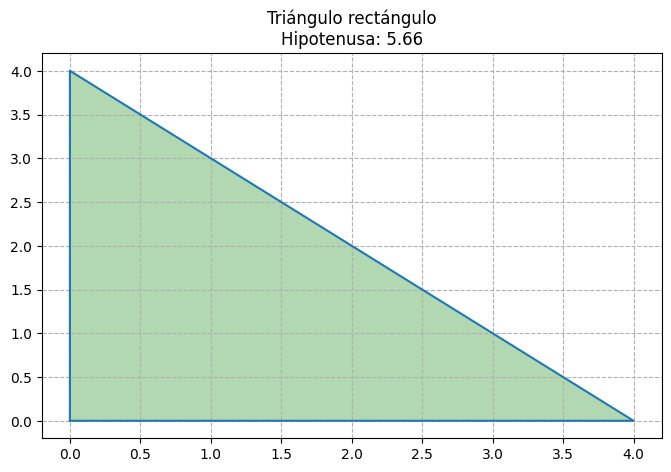

In [ ]:
from matplotlib.lines import lineStyles
import math

def hipotenusa(a,b):
  hipotenusa = math.sqrt(a**2 + b **2)

# Coordenadas del triángulo
  x = [0, a, 0, 0]
  y = [0, 0, b, 0]

  plt.figure(figsize=(8,5))
  plt.plot(x,y)
  plt.fill(x,y, 'green', alpha = 0.3)
  plt.grid(True, linestyle = '--')
  plt.title(f"Triángulo rectángulo\nHipotenusa: {hipotenusa:.2f}")
  plt.show()

hipotenusa(4,4)

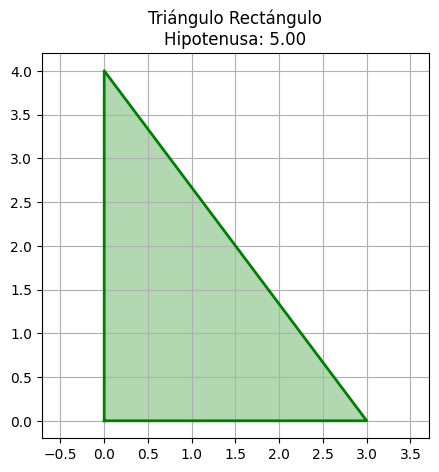

In [ ]:
def pitagoras_visual(cateto_a, cateto_b):
    hipotenusa = math.sqrt(cateto_a**2 + cateto_b**2)

    # Coordenadas del triángulo
    x = [0, cateto_a, 0, 0]
    y = [0, 0, cateto_b, 0]

    plt.figure(figsize=(5,5))
    plt.plot(x, y, 'g-', linewidth=2)
    plt.fill(x, y, 'green', alpha=0.3)
    plt.title(f"Triángulo Rectángulo\nHipotenusa: {hipotenusa:.2f}")
    plt.axis('equal')
    plt.grid(True)
    plt.show()

pitagoras_visual(3, 4) # El famoso triángulo 3-4-5

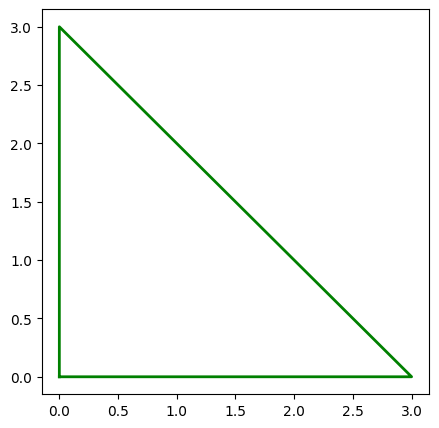

In [ ]:
x = [0,3,0,0]
y = [0,0,3,0]

plt.figure(figsize=(5,5))
plt.plot(x,y, 'g-', linewidth=2)
plt.show()

In [ ]:
import numpy as np
def escalar(a,b):
  suma = a+b
  resta = a-b
  multiplicacion = a*b
  division = a/b
  print('---Los Resultados son👌---')
  print(f'La suma es {suma}, \n la resta es {resta}, \n la multiplicacion es {multiplicacion}, \n la division es {division}')

escalar(5,8)

---Los Resultados son👌---
La suma es 13, 
 la resta es -3, 
 la multiplicacion es 40, 
 la division es 0.625


In [ ]:
# Escalar vs matriz
import numpy as np
escalar = 2
matriz = np.array([[10,20],
                  [30,40] ])
resultado = escalar / matriz
print(f'El resultado es {resultado}')

El resultado es [[0.2        0.1       ]
 [0.06666667 0.05      ]]


In [ ]:
# Operacion de vectores
# Vectores 2x2
import numpy as np
vectorA = np.array([[2,3],
                    [5,4]])
vectorB = np.array([[5,9],
                    [2,5]])

suma = vectorA + vectorB
resta = vectorA - vectorB
multiplicacion = vectorA * vectorB
division = vectorA / vectorB

print(f'Los resultados de operaciones de vectores son: \n suma:\n {suma}, \n resta:\n {resta}, \n multiplicacion:\n {multiplicacion}, \n division:\n {division}')


Los resultados de operaciones de vectores son: 
 suma:
 [[ 7 12]
 [ 7  9]], 
 resta:
 [[-3 -6]
 [ 3 -1]], 
 multiplicacion:
 [[10 27]
 [10 20]], 
 division:
 [[0.4        0.33333333]
 [2.5        0.8       ]]


In [ ]:
# La magnitud o modulo o la norma de un vector

a = [2,3]
magnitud = np.linalg.norm(a)
print(f'La norma es: {magnitud:.2f}')

La norma es: 3.61


In [ ]:
# La magnitud o modulo o la norma de un vector creando una función
import math
a = [2,3]
def magnitud(a):
  x = a[0]
  y = a[1]
  magnitud = math.sqrt(x**2 + y**2)
  print(f'La norma es: {magnitud:.2f}')

magnitud(a)


La norma es: 3.61


In [ ]:
# Vector unitario es útil cuando solo nos importa la dirección y no el tamaño

a = [2,3]
magnitud = np.linalg.norm(a)
vector_unitario = a / magnitud

print(f'El vector unitario es: {vector_unitario}')



El vector unitario es: [0.5547002  0.83205029]


In [ ]:
# Distancia entre vectores
a = np.array([2,3])
b = np.array([3,5])
distancia = np.linalg.norm(a-b)
print(f'La distancia entre los vectores es de: {distancia:.2f}')

La distancia entre los vectores es de: 2.24


In [ ]:
# Producto Escalar o producto punto
a = np.array([2,3])
b = np.array([4,7])
producto_escalar = np.dot(a,b)
print(f'El producto escalar es: {producto_escalar}')

El producto escalar es: 29


In [ ]:
# Matriz transpuesta
A = np.array([[2,3],
             [4,2] ])

transpuesta = A.T

print(f'La matriz transpuesta es: \n {transpuesta}')

La matriz transpuesta es: 
 [[2 4]
 [3 2]]


/tmp/ipykernel_13606/1765216386.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_13606/1765216386.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


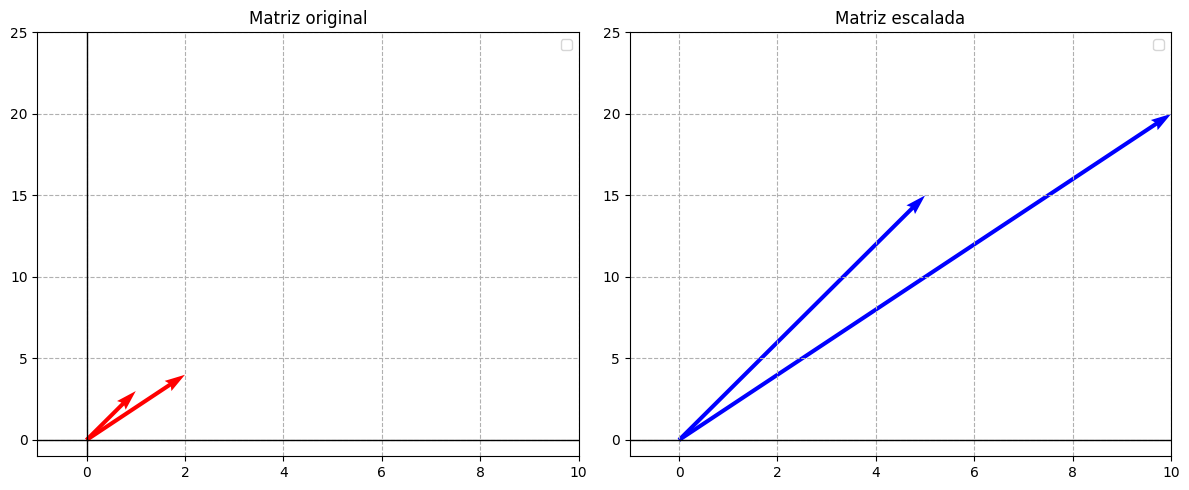

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1,2],
             [3,4] ])

escalar = 5

resultado = A * 5

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

ax1.quiver([0,0], [0,0], A[0,:], A[1,:], angles = 'xy', scale_units = 'xy', scale = 1, color = 'red')
ax1.set_title('Matriz original')
ax1.set_xlim(-1,10), ax1.set_ylim(-1,25)
ax1.legend()
ax1.grid(True, linestyle = '--')
ax1.axhline(0, color = 'black', linewidth = 1), ax1.axvline(0, color = 'black', linewidth = 1)

ax2.quiver([0,0], [0,0], resultado[0,:], resultado[1,:], color = 'blue', scale = 1, scale_units = 'xy', angles = 'xy')
ax2.set_title('Matriz escalada')
ax2.set_xlim(-1,10), ax2.set_ylim(-1,25)
ax2.legend()
ax2.grid(True, linestyle ='--')
ax2.axhline(0, color = 'black', linewidth = 1), ax2.axvline

plt.tight_layout()
plt.show()



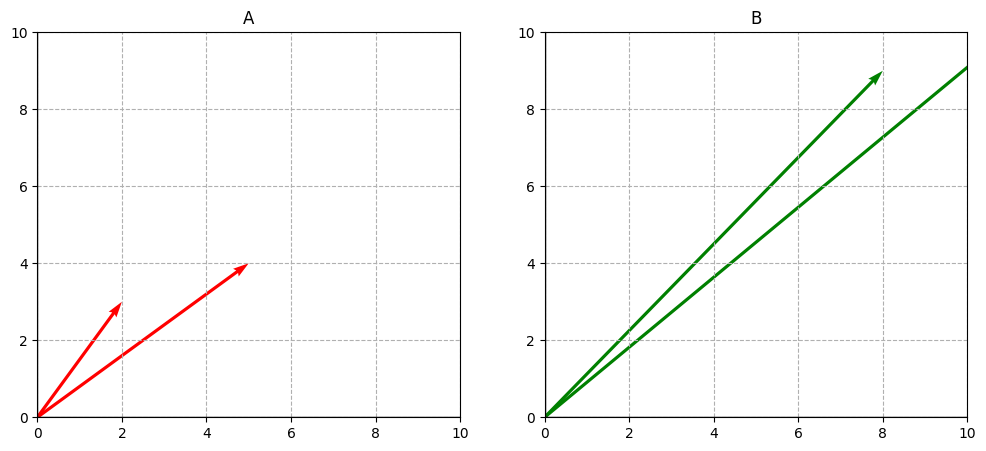

In [ ]:
escalar = 6
A = np.array([[2,5],
              [3,4]])
resultado = escalar + A

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))
#Eje 1
ax1.quiver([0,0], [0,0], A[0,:], A[1,:], angles = 'xy', scale_units = 'xy', scale = 1, color = 'red')
ax1.set_xlim(0, 10), ax1.set_ylim(0, 10)
ax1.set_title("A")
ax1.grid(True, linestyle = '--')
ax1.axhline(0, color = 'black', linewidth = 1), ax1.axvline(0, color = 'black', linewidth = 1)


#Eje 2
ax2.quiver([0,0], [0,0], resultado[0,:], resultado[1,:], angles = 'xy', scale_units = 'xy', scale = 1, color = "green")
ax2.set_xlim(0, 10), ax2.set_ylim(0, 10)
ax2.set_title("B")
ax2.grid(True, linestyle = '--')
ax2.axhline(0, color = 'black', linewidth = 1), ax2.axvline(0, color = 'black', linewidth = 1)


plt.show()

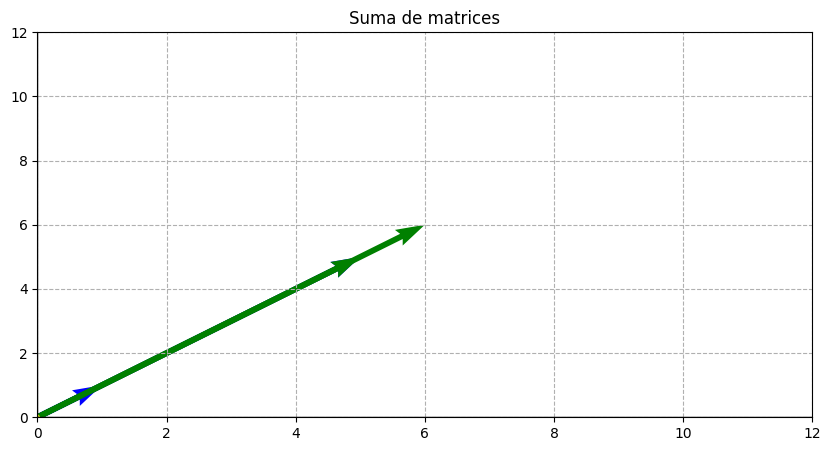

In [ ]:
A = np.array([[5,1],
              [3,1]])
B = np.array([[5,6],
              [7,8]])

resultado = A - B

plt.figure(figsize = (10,5))
plt.title('Suma de matrices')
plt.grid(True, linestyle = '--')
plt.axhline(0, color = 'black', linewidth = 1), plt.axvline(0, color = 'black', linewidth = 1)
plt.xlim(0, 12), plt.ylim(0, 12)
plt.quiver([0,0], [0,0], A[0,:], A[0,:], angles ='xy', scale_units = 'xy', scale = 1, color = 'blue')
plt.quiver([0,0], [0,0], B[0,:], B[0,:], angles ='xy', scale_units = 'xy', scale = 1, color = 'green')
plt.quiver([0,0], [0,0], resultado[0,:], resultado[0,:], angles ='xy', scale_units = 'xy', scale = 1, color = 'yellow')
plt.show()

[-18  16  -3]


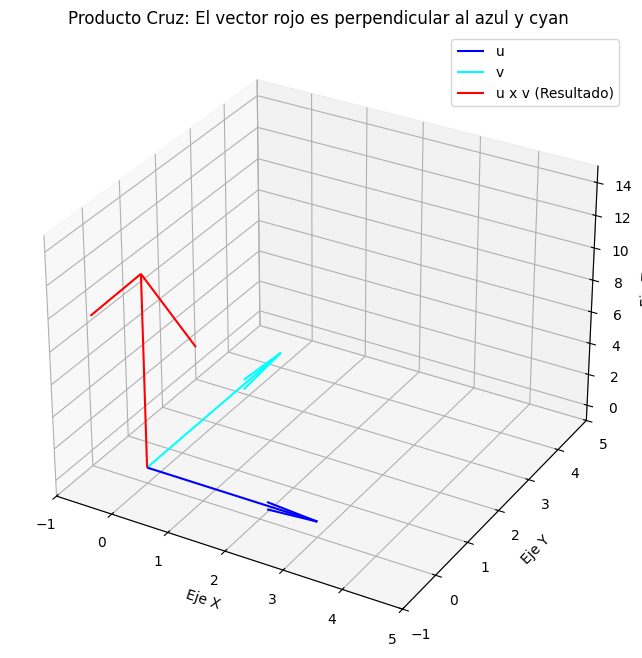

In [ ]:
A = np.array([2,3,4])
B = np.array([5,6,2])

resultado = np.cross(A,B)
print(resultado)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

u = np.array([3, 0, 0])
v = np.array([0, 4, 0])
w = np.cross(u, v)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# El origen de todos los vectores
origin = [0, 0, 0]

# Graficamos las flechas
# ax.quiver(origen_x, y, z, direccion_x, y, z)
ax.quiver(0, 0, 0, u[0], u[1], u[2], color='blue', label='u')
ax.quiver(0, 0, 0, v[0], v[1], v[2], color='cyan', label='v')
ax.quiver(0, 0, 0, w[0], w[1], w[2], color='red', label='u x v (Resultado)')

# Configuración de límites
ax.set_xlim([-1, 5]), ax.set_ylim([-1, 5]), ax.set_zlim([-1, 15])
ax.set_xlabel('Eje X'), ax.set_ylabel('Eje Y'), ax.set_zlabel('Eje Z')
ax.legend()
plt.title("Producto Cruz: El vector rojo es perpendicular al azul y cyan")
plt.show()

In [ ]:
A = np.array([2,3])
B = np.array([4,5])
resultado = np.dot(A,B)
print(resultado)

23


In [ ]:
A = np.array([[3,4] ,
             [2,5] ])

resultado = np.linalg.det(A)
print(resultado)

if resultado != 0:
  print('La matriz es invertible')
else:
  print('La matriz no es invertible')


7.000000000000001
La matriz es invertible


In [ ]:
A = np.array([[3,4] ,
             [2,5] ])

resultado = np.linalg.det(A)
print(resultado)

if resultado != 0:
  inversa = np.linalg.inv(A)
  print(f'La inversa de la matriz es: \n {inversa}')
else:
  print('La matriz no es invertible')

7.000000000000001
La inversa de la matriz es: 
 [[ 0.71428571 -0.57142857]
 [-0.28571429  0.42857143]]


In [ ]:
import numpy as np

A = np.array([[3, 4],
              [2, 5]])

# Calculamos valores y vectores propios
valores, vectores = np.linalg.eig(A)

print("Valores Propios (Eigenvalues):")
print(valores)

print("\nVectores Propios (Eigenvectors):")
print(vectores)

Valores Propios (Eigenvalues):
[1. 7.]

Vectores Propios (Eigenvectors):
[[-0.89442719 -0.70710678]
 [ 0.4472136  -0.70710678]]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ejemplo_colab_datos.xlsx to ejemplo_colab_datos.xlsx


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("ejemplo_colab_datos.xlsx")
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      50 non-null     int64  
 1   Sexo                    50 non-null     object 
 2   Edad_años               50 non-null     int64  
 3   Semestre                50 non-null     int64  
 4   Tipo_Universidad        50 non-null     object 
 5   Departamento            50 non-null     object 
 6   Horas_Sueño_día         50 non-null     float64
 7   Cafeína_tazas_día       50 non-null     float64
 8   Horas_Estudio_semana    50 non-null     float64
 9   Días_Ejercicio_semana   50 non-null     int64  
 10  Horas_Pantalla_día      50 non-null     float64
 11  MBI_Agotamiento         50 non-null     int64  
 12  MBI_Despersonalización  50 non-null     int64  
 13  MBI_Eficacia_Académica  50 non-null     int64  
 14  Clasificación_Burnout   50 non-null     obje

,ID,Edad_años,Semestre,Horas_Sueño_día,Cafeína_tazas_día,Horas_Estudio_semana,Días_Ejercicio_semana,Horas_Pantalla_día,MBI_Agotamiento,MBI_Despersonalización,MBI_Eficacia_Académica,Calificación_Promedio,Consumo_Alcohol_semana
count,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000
mean,25.50000,22.680000,5.460000,5.78400,3.122000,33.006000,3.520000,7.606000,21.100000,8.980000,36.820000,3.546000,4.80000
std,14.57738,2.809895,2.779003,0.98858,1.697332,12.983465,2.557422,2.598619,6.569099,3.443361,5.734571,0.362086,3.18158
min,1.00000,18.000000,1.000000,3.90000,0.100000,13.100000,0.000000,2.300000,7.000000,2.000000,25.000000,2.700000,0.00000
25%,13.25000,21.000000,4.000000,4.92500,1.725000,22.125000,1.000000,5.925000,17.000000,7.000000,33.250000,3.400000,2.25000
50%,25.50000,22.500000,5.000000,5.75000,3.450000,33.050000,3.500000,7.300000,21.000000,9.000000,37.000000,3.500000,4.00000
75%,37.75000,25.000000,8.000000,6.30000,4.300000,46.000000,5.750000,9.675000,26.750000,11.750000,41.000000,3.700000,8.00000
max,50.00000,27.000000,10.000000,7.90000,6.000000,54.300000,7.000000,12.000000,35.000000,17.000000,48.000000,4.500000,10.00000


In [ ]:
df.dtypes

,0
ID,int64
Sexo,object
Edad_años,int64
Semestre,int64
Tipo_Universidad,object
Departamento,object
Horas_Sueño_día,float64
Cafeína_tazas_día,float64
Horas_Estudio_semana,float64
Días_Ejercicio_semana,int64


In [ ]:
# Pretratamiento
# Convirtiendo objetos a categorias
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].astype('category')
# Convirtiendo ID como objeto
df['ID'] = df['ID'].astype('object')

# VISUALIZANDO
df.dtypes
df.head(3)

,ID,Sexo,Edad_años,Semestre,Tipo_Universidad,Departamento,Horas_Sueño_día,Cafeína_tazas_día,Horas_Estudio_semana,Días_Ejercicio_semana,Horas_Pantalla_día,MBI_Agotamiento,MBI_Despersonalización,MBI_Eficacia_Académica,Clasificación_Burnout,Calificación_Promedio,Consumo_Alcohol_semana
0,1,Masculino,18,5,Pública,Bolívar,7.0,0.8,14.6,1,9.4,16,8,42,Sin burnuot,3.4,10
1,2,F,21,8,privada,Antioquia,5.6,4.6,17.2,4,6.2,26,17,34,Burnout moderado,3.6,1
2,3,F,23,10,PRIVADA,Antioquia,6.1,4.4,34.1,6,11.7,23,5,30,Burnoout moderado,3.4,1


In [ ]:
print(df['Sexo'].unique)

<bound method Series.unique of 0     Masculino
1             F
2             F
3             M
4             M
5     Masculino
6             F
7             F
8             m
9     Masculino
10            F
11            M
12            F
13            M
14            M
15            F
16            M
17            F
18            M
19    Masculino
20            F
21            m
22            F
23            F
24    Masculino
25            M
26            M
27    MASCULINO
28            F
29            F
30            F
31            F
32            F
33            F
34            F
35            M
36            F
37            M
38            F
39    MASCULINO
40     FEMENINO
41            F
42            M
43            F
44            M
45            F
46            F
47            M
48            F
49            M
Name: Sexo, dtype: category
Categories (6, object): ['F', 'FEMENINO', 'M', 'MASCULINO', 'Masculino', 'm']>


In [ ]:
# Vamos a cambiar los errores gramaticales
df['Sexo'] = df['Sexo'].replace({'Masculino':'M', 'm':'M', 'MASCULINO':'M', 'FEMENINO':'F'})
print(df['Sexo'].unique)

df['Tipo_Universidad'] = df['Tipo_Universidad'].replace({'Publica':'Pública', 'publica':'Pública', 'Públca':'Pública',
                                                         'PRIVADA':'Privada', 'privada':'Privada'})
print(df['Tipo_Universidad'].unique)

df['Departamento'] = df['Departamento'].replace({'Antioqia':'Antioquia', 'Cundimarca':'Cundinamarca',
                                                 'Bolivar':'Bolívar', 'Atlantico':'Atlántico'})
print(df['Departamento'].unique)

df['Clasificación_Burnout'] = df['Clasificación_Burnout'].replace({'Sin burnuot': 'Sin burnout',
                                                                   'Sin burnot':'Sin burnout',
                                                                   'Burnoout moderado':'Burnout moderado',
                                                                   'Burnuot moderado':'Burnout moderado',
                                                                   'Burnout moerado': 'Burnout moderado',
                                                                   'Burnuot severo':'Burnout severo',
                                                                   'Burnout Moderado':'Burnout moderado',
                                                                    'Sin Burnout':'Sin burnout',
                                                                   'burnout moderado':'Burnout moderado',
                                                                   'burnout severo':'Burnout severo'  })
print(df['Clasificación_Burnout'].unique)

<bound method Series.unique of 0     M
1     F
2     F
3     M
4     M
5     M
6     F
7     F
8     M
9     M
10    F
11    M
12    F
13    M
14    M
15    F
16    M
17    F
18    M
19    M
20    F
21    M
22    F
23    F
24    M
25    M
26    M
27    M
28    F
29    F
30    F
31    F
32    F
33    F
34    F
35    M
36    F
37    M
38    F
39    M
40    F
41    F
42    M
43    F
44    M
45    F
46    F
47    M
48    F
49    M
Name: Sexo, dtype: category
Categories (2, object): ['F', 'M']>
<bound method Series.unique of 0     Pública
1     Privada
2     Privada
3     Pública
4     Pública
5     Privada
6     Privada
7     Pública
8     Privada
9     Pública
10    Pública
11    Pública
12    Pública
13    Privada
14    Pública
15    Privada
16    Pública
17    Privada
18    Pública
19    Pública
20    Privada
21    Pública
22    Pública
23    Privada
24    Privada
25    Pública
26    Pública
27    Privada
28    Pública
29    Pública
30    Pública
31    Privada
32    Pública
33    Privad

/tmp/ipykernel_27730/1952507103.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Sexo'] = df['Sexo'].replace({'Masculino':'M', 'm':'M', 'MASCULINO':'M', 'FEMENINO':'F'})
/tmp/ipykernel_27730/1952507103.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Tipo_Universidad'] = df['Tipo_Universidad'].replace({'Publica':'Pública', 'publica':'Pública', 'Públca':'Pública',
/tmp/ipykernel_27730/1952507103.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be use

In [ ]:
print(df.head(5))

  ID Sexo  Edad_años  Semestre Tipo_Universidad  Departamento  \
0  1    M         18         5          Pública       Bolívar   
1  2    F         21         8          Privada     Antioquia   
2  3    F         23        10          Privada     Antioquia   
3  4    M         21         5          Pública       Bolívar   
4  5    M         27         3          Pública  Cundinamarca   

   Horas_Sueño_día  Cafeína_tazas_día  Horas_Estudio_semana  \
0              7.0                0.8                  14.6   
1              5.6                4.6                  17.2   
2              6.1                4.4                  34.1   
3              5.9                5.2                  27.1   
4              5.8                2.8                  22.1   

   Días_Ejercicio_semana  Horas_Pantalla_día  MBI_Agotamiento  \
0                      1                 9.4               16   
1                      4                 6.2               26   
2                      6           

In [ ]:
#Datos estadísticos
df.describe()
df['Sexo'].value_counts()
df['Tipo_Universidad'].value_counts()
df['Departamento'].value_counts()

,count
Departamento,
Bolívar,6
Cundinamarca,6
Boyacá,6
Valle del Cauca,6
Antioquia,5
Santander,4
Atlántico,4
Nariño,3
Córdoba,3


In [ ]:
seleccion = [
    'Horas_Sueño_día',
    'Cafeína_tazas_día',
    'Horas_Estudio_semana',
    'Días_Ejercicio_semana',
    'Horas_Pantalla_día',
    'MBI_Agotamiento',
    'Calificación_Promedio'
]

filtrado = df[seleccion]
print(filtrado.head(4))

   Horas_Sueño_día  Cafeína_tazas_día  Horas_Estudio_semana  \
0              7.0                0.8                  14.6   
1              5.6                4.6                  17.2   
2              6.1                4.4                  34.1   
3              5.9                5.2                  27.1   

   Días_Ejercicio_semana  Horas_Pantalla_día  MBI_Agotamiento  \
0                      1                 9.4               16   
1                      4                 6.2               26   
2                      6                11.7               23   
3                      5                 6.5               23   

   Calificación_Promedio  
0                    3.4  
1                    3.6  
2                    3.4  
3                    3.1  


In [ ]:
matriz_corr = filtrado.corr()
print(matriz_corr)

                       Horas_Sueño_día  Cafeína_tazas_día  \
Horas_Sueño_día               1.000000          -0.451504   
Cafeína_tazas_día            -0.451504           1.000000   
Horas_Estudio_semana         -0.467107          -0.061007   
Días_Ejercicio_semana         0.196283           0.194303   
Horas_Pantalla_día           -0.031977           0.006077   
MBI_Agotamiento              -0.633293           0.307845   
Calificación_Promedio         0.276335          -0.194611   

                       Horas_Estudio_semana  Días_Ejercicio_semana  \
Horas_Sueño_día                   -0.467107               0.196283   
Cafeína_tazas_día                 -0.061007               0.194303   
Horas_Estudio_semana               1.000000              -0.080735   
Días_Ejercicio_semana             -0.080735               1.000000   
Horas_Pantalla_día                -0.091121               0.280811   
MBI_Agotamiento                    0.544404               0.185132   
Calificación_Promedio

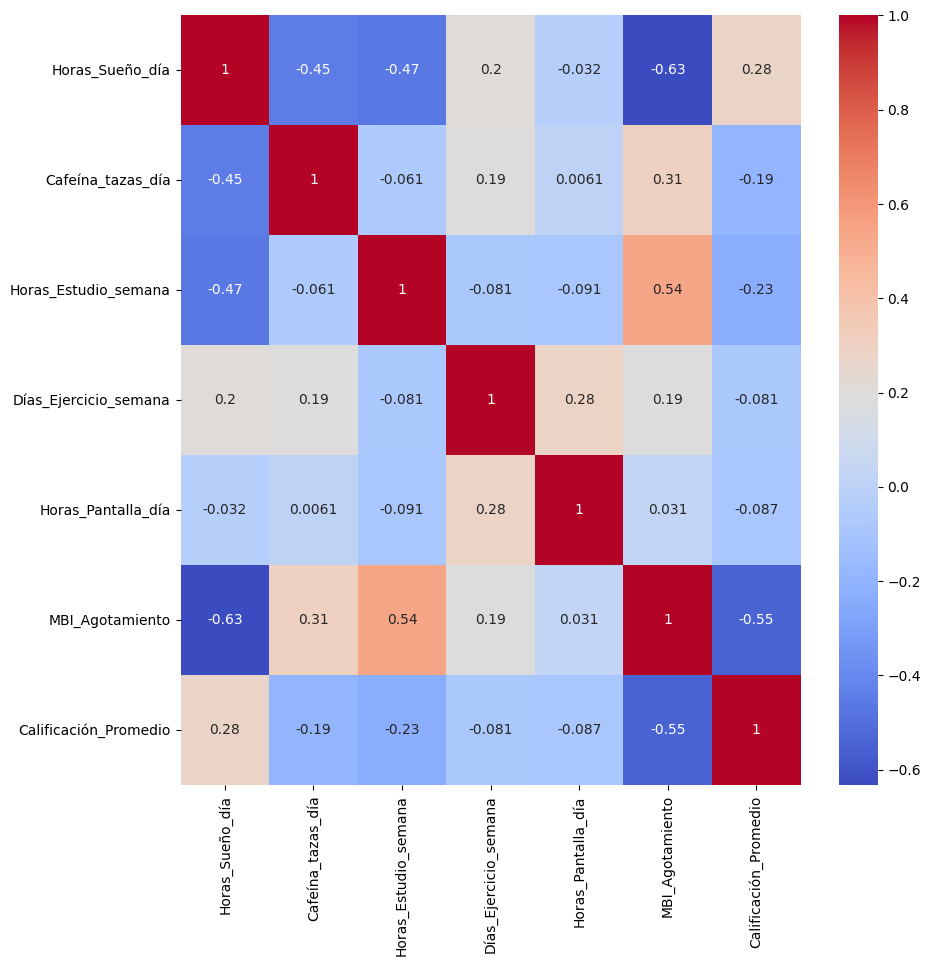

In [ ]:
plt.figure(figsize = (10,10))
sns.heatmap(matriz_corr, annot = True, cmap = 'coolwarm')
plt.show()

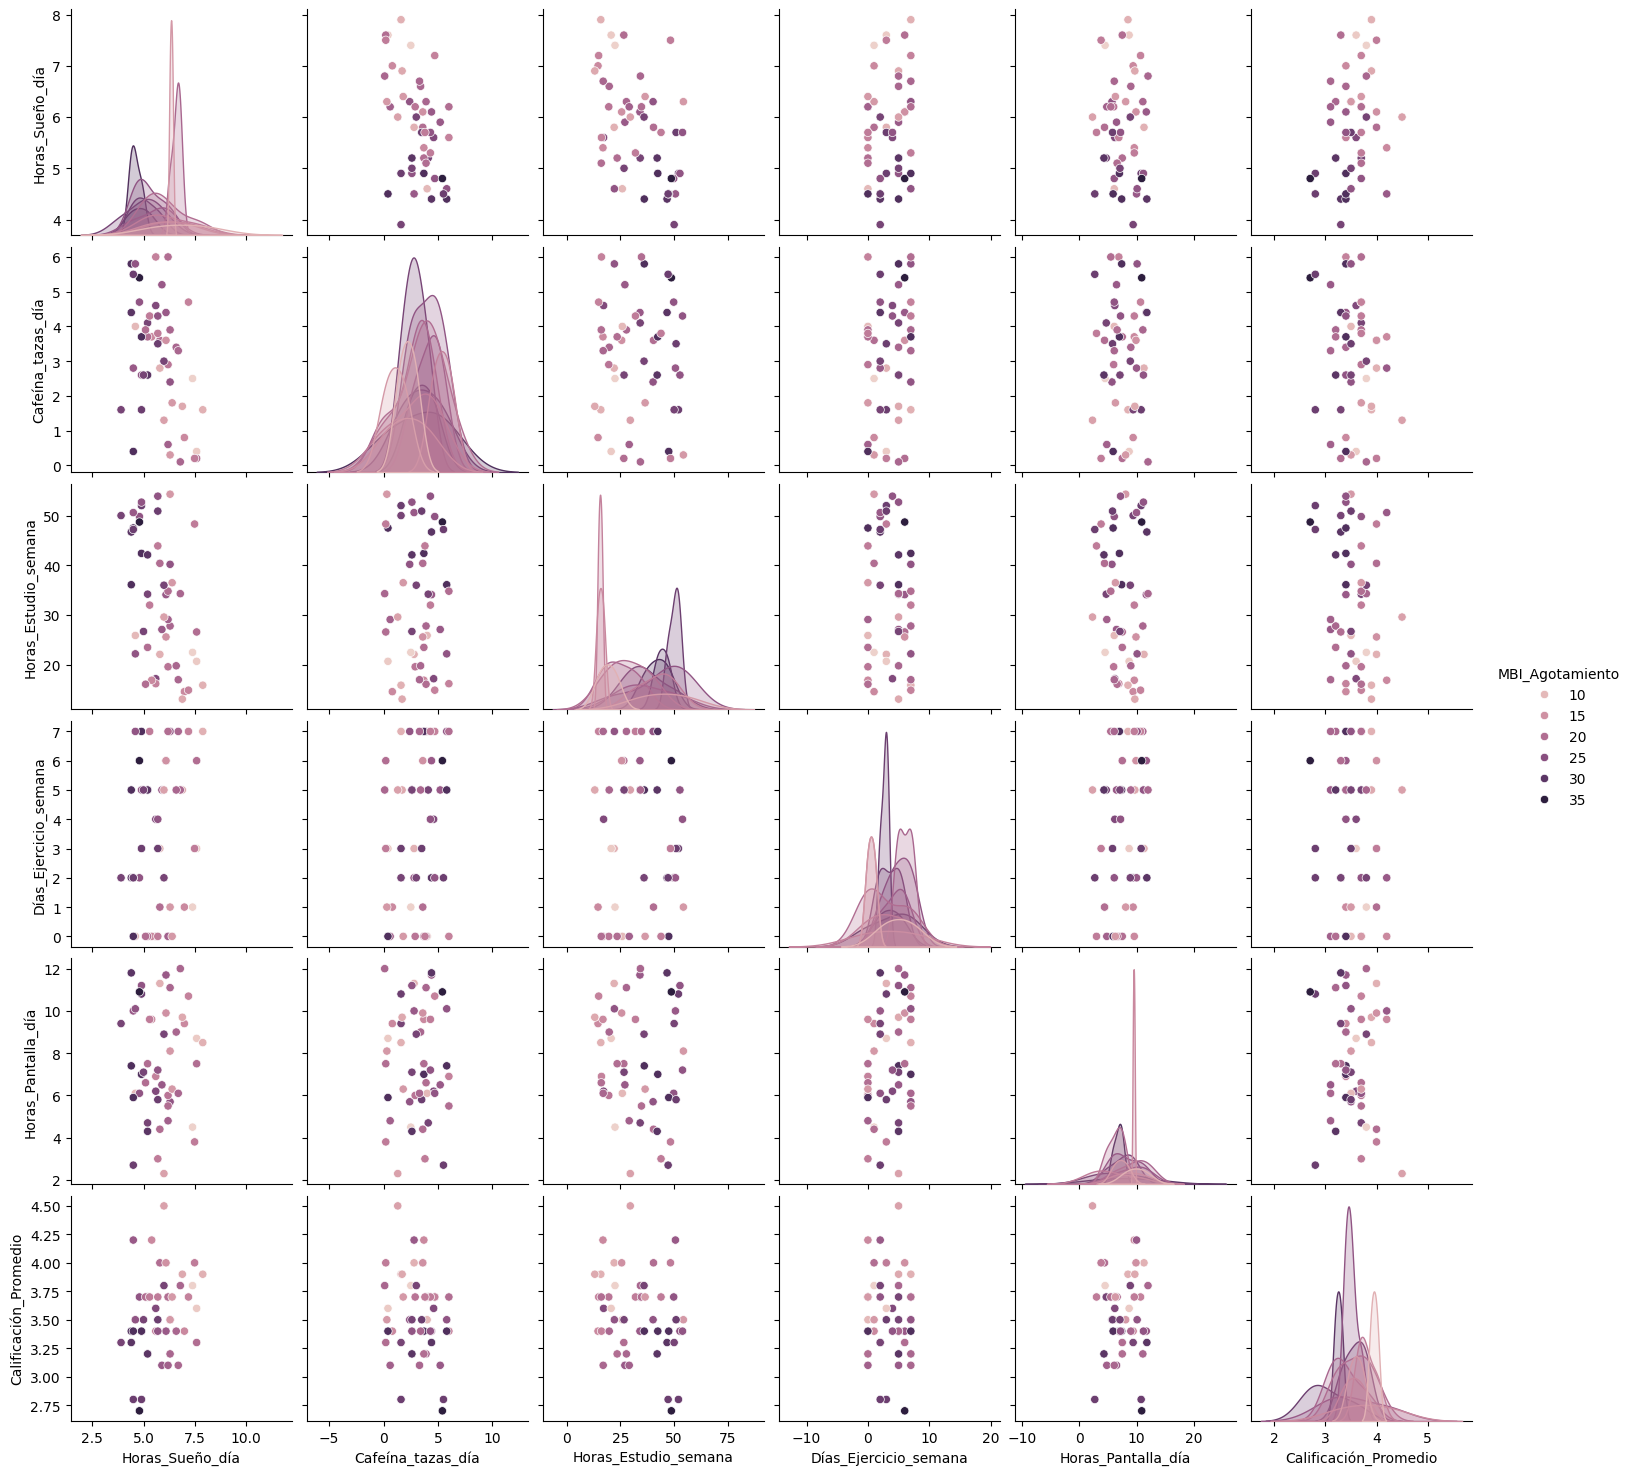

In [ ]:
sns.pairplot(filtrado, hue = 'MBI_Agotamiento')
plt.show()

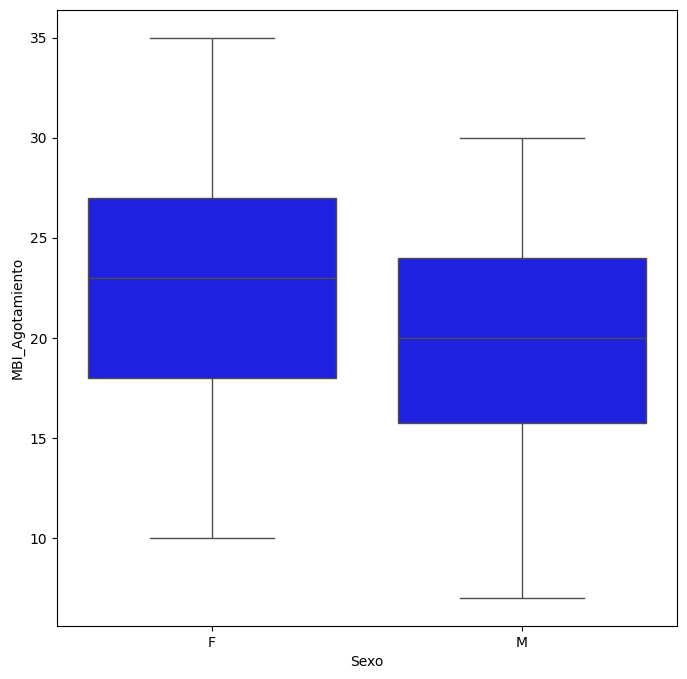

In [ ]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df, x='Sexo', y='MBI_Agotamiento', color = 'blue')
plt.show()

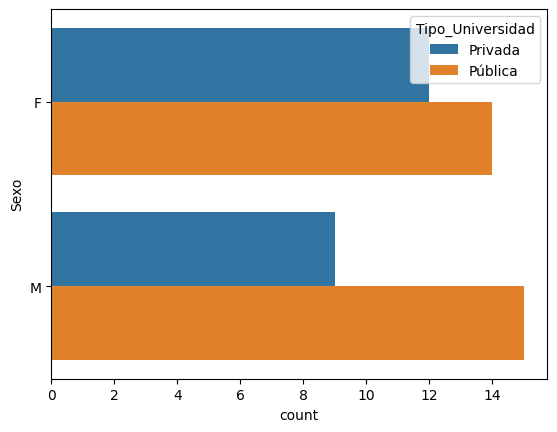

In [ ]:
sns.countplot(df, y = 'Sexo', hue = 'Tipo_Universidad')
plt.show()


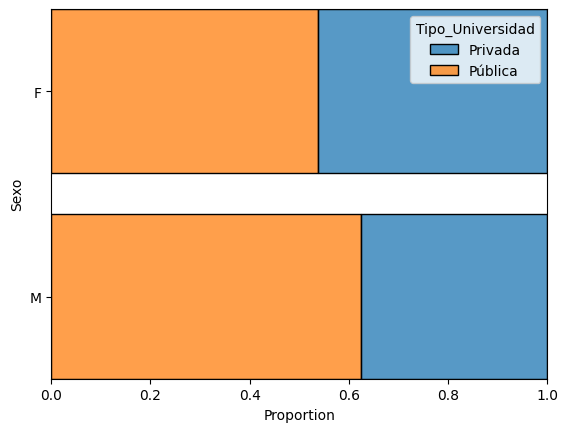

In [ ]:
sns.histplot(df, y = 'Sexo', hue = 'Tipo_Universidad', multiple = 'fill', stat = 'proportion', shrink = 0.8 )
plt.show()

In [ ]:
from scipy import stats
estadistico, valorp = stats.shapiro(df['Cafeína_tazas_día'])
print(f'El estadístico es: {estadistico:.2f}\n el valor p es: {valorp:.2f}')

El estadístico es: 0.96
 el valor p es: 0.07


In [ ]:
tabla_contingencia = pd.crosstab(df['Sexo'], df['Clasificación_Burnout'])
print(tabla_contingencia)

chi2, p, dof, ex = stats.chi2_contingency(tabla_contingencia)
print(f'El estadístico:{chi2:.2f} y el valor p: {p:.2f}')

Clasificación_Burnout  Burnout moderado  Burnout severo  Sin burnout
Sexo                                                                
F                                    19               4            3
M                                    14               3            7
El estadístico:2.42 y el valor p: 0.30


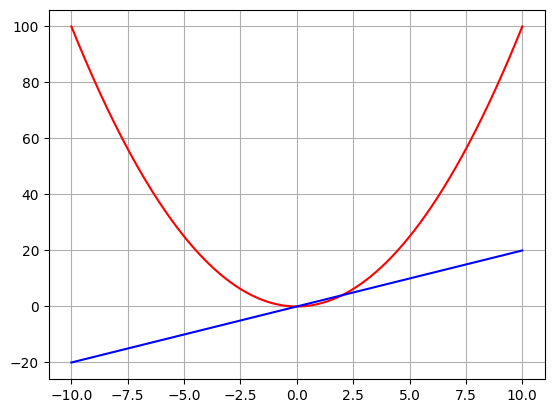

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return  x**2

x = np.linspace(-10,10,1000)

def df(f):
  h =0.000000000001
  return (f(x+h)-f(x))/h

plt.plot(x,f(x), 'r')
plt.plot(x, df(f), 'b')
plt.grid()

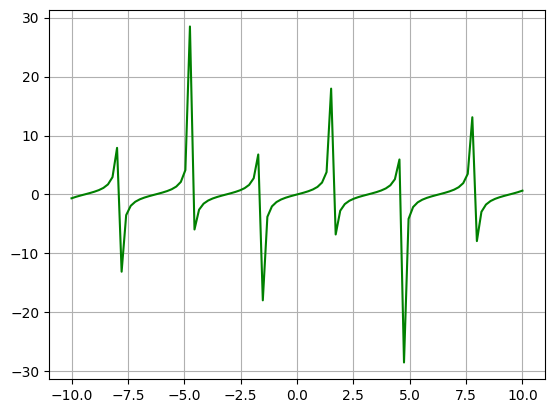

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return np.tan(x)

x = np.linspace(-10, 10, 100)

m = 5
b = 7
plt.plot(x, f(x), 'g')
plt.grid()

/tmp/ipykernel_7196/3462834114.py:5: RuntimeWarning: invalid value encountered in log2
  return np.log2(x)


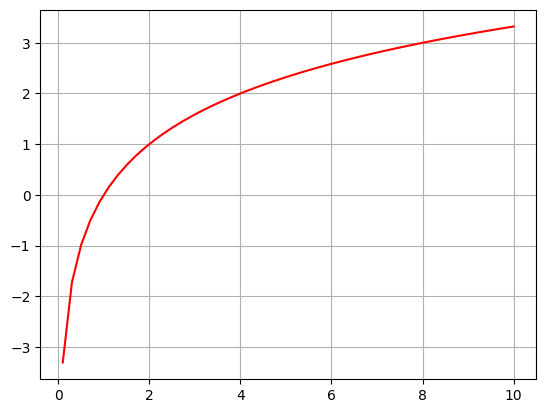

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-10,10,100)
def f(x):
  return np.log2(x)

plt.plot(x, f(x), 'r')
plt.grid()

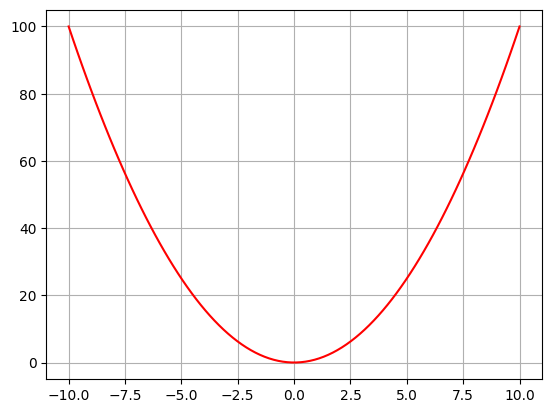

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-10,10,100)
def f(x):
  return x**2

plt.plot(x, f(x), 'r')
plt.grid()

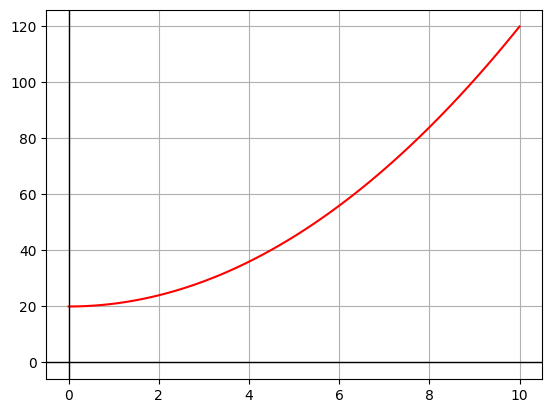

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0,10,100)
def f(x):
  return x**2

y = f(x) + 20


plt.plot(x, y, 'r')
plt.axhline(0, color = 'black', linewidth = 1)
plt.axvline(0, color = 'black', linewidth = 1)
plt.grid()

In [ ]:
# vector 1 dimension
import numpy as np
vector = np.array([2,5,3])
print(vector)

[2 5 3]


In [ ]:
# matriz que ya son dos dimensiones
matriz = np.array([[1,2,3], [1,4,5] ])
print(matriz)

[[1 2 3]
 [1 4 5]]


In [ ]:
# matriz de 3 dimensiones
matriz = np.array([[[2,4,2],[2,6,2], [3,5,6]]])
print(matriz)

[[[2 4 2]
  [2 6 2]
  [3 5 6]]]


In [ ]:
# Tensor 4d

tensor = np.array([[[[2,3], [3,6], [44,66], [45,23]]]])
print(tensor)

[[[[ 2  3]
   [ 3  6]
   [44 66]
   [45 23]]]]


In [ ]:
# arange
matriz2 = np.arange(10)
print(matriz2)

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
# matriz de identidad
matriz3 = np.eye(3)
print(matriz3)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
# matriz diagonal
matriz4 = np.diag([1,2,3])
print(matriz4)
print(matriz4.shape)
print(matriz4.size)
print(matriz4.ndim)

[[1 0 0]
 [0 2 0]
 [0 0 3]]
(3, 3)
9
2


In [ ]:
matriz5 = np.array([[1,2,3], [4,5,6]])
print(matriz5)
print(matriz5.shape)
print(matriz5.size)
print(matriz5.ndim)
print(matriz5.dtype)

[[1 2 3]
 [4 5 6]]
(2, 3)
6
2
int64


In [ ]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

suma = A + B
print("Suma de matrices:\n", suma)

Suma de matrices:
 [[ 6  8]
 [10 12]]


In [ ]:
producto = np.dot(A, B)
print("Producto de matrices:\n", producto)

Producto de matrices:
 [[19 22]
 [43 50]]


In [ ]:
determinante = np.linalg.det(A)
print("Determinante de A:", determinante)

Determinante de A: -2.0000000000000004


In [ ]:
inversa = np.linalg.inv(A)
print("Inversa de A:\n", inversa)

Inversa de A:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [ ]:
valores_propios, vectores_propios = np.linalg.eig(A)
print("Valores propios de A:\n", valores_propios)
print("Vectores propios de A:\n", vectores_propios)

Valores propios de A:
 [-0.37228132  5.37228132]
Vectores propios de A:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [ ]:
B = np.array([1, 2])
X = np.linalg.solve(A, B)
print("Solución del sistema AX = B:\n", X)

Solución del sistema AX = B:
 [0.  0.5]


In [ ]:
# slice
A = np.array([[1, 2], [3, 4]])
print(A[1:3])

[[3 4]]


In [ ]:
# Uso de random y randint
matriz6 = np.random.random(3)
print(matriz6)
matriz7 = np.random.randint(1,3, size = (3,3))
print(matriz7)

[0.51010396 0.81822889 0.98659503]
[[2 1 2]
 [2 1 2]
 [1 2 2]]


In [ ]:
matriz7[:2,:3]

array([[2, 1, 2],
       [2, 1, 2]])

In [ ]:
# concatenar
a = np.array([1,2,3])
b = np.array([4,5,6])
c = np.concatenate((a,b))
print(c)

[1 2 3 4 5 6]


In [ ]:
# operaciones con array
d = np.random.randint(0,10,3)
e = np.array([10,20,30])
print(d)
print(d+e)


[7 8 6]
[17 28 36]


In [ ]:
# dividiendo con split
array = np.arange(3)
split = array.split(2)

In [ ]:
# Matriz transpuesta
import numpy as np
import matplotlib.pyplot as plt
matrix = np.array([[1,2,3], [4,5,6], [7,8,9]])
matrix_transpuesta = matrix.T
print(matrix)
print(matrix_transpuesta)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [ ]:
# Reshape
array = np.arange(9)
print(array)
array = array.reshape(3,3)
print(array)

[0 1 2 3 4 5 6 7 8]
[[0 1 2]
 [3 4 5]
 [6 7 8]]


In [ ]:
# reverse
array = np.array([1,2,3,4,5])
print(array)
array = array[::-1]
print(array)

[1 2 3 4 5]
[5 4 3 2 1]


In [ ]:
# flatering es pasar de un arreglo multidimensional a uno unidimensional para entrenar el modelo, por ejemplo imagenes
matrix = np.array([[1,2,3], [4,5,6], [7,8,9]])
aplanada = matrix.flatten()
print(matrix)
print(aplanada)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[1 2 3 4 5 6 7 8 9]


In [ ]:
from numpy.linalg import det
# operaciones con matrices
a = np.array([1,2,3])
b = np.array([4,5,6])
suma = a+b
print(suma)
multiplicacion = np.dot(a,b)
print(multiplicacion)
c = np.array([[1,2], [3,4]])
determinante = np.linalg.det(c)
print(determinante)
inversa = np.linalg.inv(c)
print(inversa)


[5 7 9]
32
-2.0000000000000004
[[-2.   1. ]
 [ 1.5 -0.5]]


In [ ]:
# Ejemplos de lectura de archivos en pandas
import pandas as pd

data_excel = pd.read_excel('ejemplo_colab_datos.xlsx')
data_csv = pd.read_csv('ejemplo_colab_datos.csv')
data_json = pd.read_json('ejemplo_colab_datos.json')

FileNotFoundError: [Errno 2] No such file or directory: 'ejemplo_colab_datos.xlsx'

In [ ]:
# Pasar array a dataframe
matrix = np.array([[1,2,3], [4,5,6], [7,8,9]])
df = pd.DataFrame(matrix, columns = ['A', 'B','C'] )
print(df)

   A  B  C
0  1  2  3
1  4  5  6
2  7  8  9


In [ ]:
import pandas as pd
import numpy as np
n = 20
sexo = np.random.choice(['M','F'], n)
Edad = np.random.normal(18,20,n)
altura = np.random.normal(1.6,0.1,n)
peso = np.random.normal(60,10,n)
Clasificacion_IMC = np.random.choice(['Normopeso','Sobrepeso','Obesidad'], n)
Exposicion = np.random.choice(['Activo', 'Inactivo'], n)
Estrato = np.random.choice([1,2,3,4,5], n)
Tipo_colegio = np.random.choice(['Publico','Privado'], n)

df =pd.DataFrame({
    'ID': range(1, n+1),
    'Sexo': sexo,
    'Edad': Edad,
    'Altura': altura,
    'Peso': peso,
    'Clasificacion_IMC': Clasificacion_IMC,
    'Exposicion': Exposicion,
    'Estrato': Estrato,
    'Tipo_colegio': Tipo_colegio
})
print(f"{df.head()}")

   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    M  83.910369  1.840878  60.070434          Obesidad     Activo   
1   2    F  -1.284306  1.597201  42.317268          Obesidad     Activo   
2   3    F  29.732185  1.661019  47.433967         Normopeso   Inactivo   
3   4    F  40.956489  1.593114  57.646564         Sobrepeso   Inactivo   
4   5    F  -1.114376  1.566049  39.571466         Normopeso     Activo   

   Estrato Tipo_colegio  
0        1      Publico  
1        1      Privado  
2        5      Publico  
3        4      Publico  
4        3      Publico  


In [ ]:
# Nombre de columnas
num_rows, num_columns = df.shape
print(f"Número de filas: {num_rows}")
print(f"Número de columnas: {num_columns}")

Número de filas: 20
Número de columnas: 9


In [ ]:
# Uso de Iloc para filas
ejemplo = df.iloc[0]
print(ejemplo)

ejemplo2 = df.iloc[:3]
print(ejemplo2)

ID                           1
Sexo                         F
Edad                  7.577371
Altura                1.691931
Peso                 71.999796
Clasificacion_IMC    Sobrepeso
Exposicion            Inactivo
Estrato                      1
Tipo_colegio           Publico
Name: 0, dtype: object
   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    F   7.577371  1.691931  71.999796         Sobrepeso   Inactivo   
1   2    M   2.924011  1.585724  61.798041          Obesidad   Inactivo   
2   3    M  23.241621  1.545737  49.711265         Sobrepeso   Inactivo   

   Estrato Tipo_colegio  
0        1      Publico  
1        3      Publico  
2        5      Publico  


In [ ]:
# Uso de loc para extraer subsets en filas
fila1 = df.loc[0]
print(fila1)

fila1_3 = df.loc[0:3]
print(fila1_3)


ID                           1
Sexo                         F
Edad                  7.577371
Altura                1.691931
Peso                 71.999796
Clasificacion_IMC    Sobrepeso
Exposicion            Inactivo
Estrato                      1
Tipo_colegio           Publico
Name: 0, dtype: object
   ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0   1    F   7.577371  1.691931  71.999796         Sobrepeso   Inactivo   
1   2    M   2.924011  1.585724  61.798041          Obesidad   Inactivo   
2   3    M  23.241621  1.545737  49.711265         Sobrepeso   Inactivo   
3   4    M  31.820384  1.361589  64.154556         Sobrepeso     Activo   

   Estrato Tipo_colegio  
0        1      Publico  
1        3      Publico  
2        5      Publico  
3        5      Privado  


In [ ]:
# Extraer una columna
extraida = df.loc[:,'Sexo']
print(extraida)

0     F
1     M
2     M
3     M
4     F
5     M
6     M
7     F
8     M
9     F
10    M
11    F
12    F
13    F
14    F
15    M
16    F
17    F
18    M
19    M
Name: Sexo, dtype: object


In [ ]:
extraer2 = df.iloc[:,1:5]
print(extraer2)

   Sexo       Edad    Altura       Peso
0     M  36.517692  1.629767  82.352043
1     F  15.302954  1.582148  55.979617
2     M  -9.009366  1.659183  57.588730
3     F  20.213571  1.639008  58.070536
4     M   3.252160  1.515831  54.930169
5     F  31.991027  1.710376  71.323485
6     M -10.794803  1.663349  72.079671
7     F  -0.717275  1.589029  41.644925
8     M  10.164252  1.597395  61.870053
9     F  11.769775  1.697253  43.526529
10    M  14.733858  1.537032  68.971450
11    F  40.987346  1.537307  79.293046
12    M  22.135287  1.632325  54.154357
13    M   9.372060  1.547710  63.802647
14    F -12.243106  1.608708  70.934745
15    F   2.929155  1.716290  64.010261
16    F  26.610652  1.511448  54.491606
17    F   0.655670  1.504427  68.814551
18    F  33.430941  1.531948  72.433687
19    M  27.389456  1.557429  49.245720


In [ ]:
extraido3 = df.loc[:,['Edad', 'Peso']]
print(extraido3)

         Edad       Peso
0   83.910369  60.070434
1   -1.284306  42.317268
2   29.732185  47.433967
3   40.956489  57.646564
4   -1.114376  39.571466
5   11.101273  66.027820
6   18.006731  77.152688
7  -11.427191  61.169025
8  -13.350157  65.576545
9   -1.820021  77.663054
10  16.825755  58.406388
11  30.439293  43.725611
12  -8.144186  70.111942
13  19.440377  48.011584
14   4.727377  69.426240
15  31.824774  51.359780
16   7.562355  63.349530
17  48.733984  51.225587
18  -1.784446  56.043519
19  11.392390  53.403960


In [ ]:
# Datos faltantes
# 1. Crear el diccionario con los datos (20 registros y valores nulos 'np.nan')
datos = {
    'ID_Empleado': range(101, 121), # IDs del 101 al 120
    'Nombre': [
        'Ana', 'Luis', 'Carlos', 'Marta', np.nan, 'Jorge', 'Elena', np.nan, 'Pedro', 'Lucia',
        'Raul', 'Carmen', 'Diego', 'Teresa', 'Victor', 'Sara', 'Pablo', np.nan, 'Rosa', 'David'
    ],
    'Edad': [
        25, 30, np.nan, 28, 35, np.nan, 42, 29, 31, 26,
        np.nan, 38, 45, np.nan, 27, 33, np.nan, 24, 30, 36
    ],
    'Departamento': [
        'Ventas', 'IT', 'Ventas', 'Marketing', 'RRHH', 'IT', np.nan, 'Ventas', 'Marketing', 'IT',
        'RRHH', np.nan, 'Ventas', 'IT', 'Marketing', 'Ventas', np.nan, 'RRHH', 'IT', 'Ventas'
    ],
    'Salario': [
        2500, 3200, 2800, 2900, np.nan, 3100, 4000, 2600, np.nan, 3300,
        2950, 3800, np.nan, 3400, 2700, 2650, 3900, np.nan, 3150, 2850
    ],
    'Puntuacion': [
        8.5, 9.0, 7.5, np.nan, 8.0, 6.5, np.nan, 7.0, 8.8, 9.2,
        np.nan, 7.8, 8.1, np.nan, 6.9, 7.4, 9.5, 8.2, np.nan, 7.6
    ]
}

# 2. Convertir el diccionario a un DataFrame de Pandas
df2 = pd.DataFrame(datos)

# 3. Establecer 'ID_Empleado' como el índice del DataFrame (Opcional pero recomendado para practicar)
df2.set_index('ID_Empleado', inplace=True)

# Mostrar los primeros registros para ver cómo quedó
print("--- Primeros 5 registros del DataFrame ---")
print(df2.head())

--- Primeros 5 registros del DataFrame ---
             Nombre  Edad Departamento  Salario  Puntuacion
ID_Empleado                                                
101             Ana  25.0       Ventas   2500.0         8.5
102            Luis  30.0           IT   3200.0         9.0
103          Carlos   NaN       Ventas   2800.0         7.5
104           Marta  28.0    Marketing   2900.0         NaN
105             NaN  35.0         RRHH      NaN         8.0


In [ ]:
# datos faltantes2
datos_faltantes = df2.isna()
print(datos_faltantes)

             Nombre   Edad  Departamento  Salario  Puntuacion
ID_Empleado                                                  
101           False  False         False    False       False
102           False  False         False    False       False
103           False   True         False    False       False
104           False  False         False    False        True
105            True  False         False     True       False
106           False   True         False    False       False
107           False  False          True    False        True
108            True  False         False    False       False
109           False  False         False     True       False
110           False  False         False    False       False
111           False   True         False    False        True
112           False  False          True    False       False
113           False  False         False     True       False
114           False   True         False    False        True
115     

In [ ]:
print(df.isnull().sum())

Nombre          3
Edad            5
Departamento    3
Salario         4
Puntuacion      5
dtype: int64


In [ ]:
# uso de dropna pero es muy radical porque elimina toda la fila o columna faltante
df_limpio = df.dropna()
print(df_limpio)
# Si tenías 20 filas, podrías quedarte con 10 si las otras tenían algún NaN.

             Nombre  Edad Departamento  Salario  Puntuacion
ID_Empleado                                                
101             Ana  25.0       Ventas   2500.0         8.5
102            Luis  30.0           IT   3200.0         9.0
110           Lucia  26.0           IT   3300.0         9.2
115          Victor  27.0    Marketing   2700.0         6.9
116            Sara  33.0       Ventas   2650.0         7.4
120           David  36.0       Ventas   2850.0         7.6


In [ ]:
# Rellenar con un valor fijo (Constante)
# Rellenar los nombres faltantes con "Anónimo"
df['Nombre'] = df['Nombre'].fillna('Anónimo')

# Rellenar departamentos vacíos con "Pendiente"
df['Departamento'] = df['Departamento'].fillna('Pendiente')

print(df)

              Nombre  Edad Departamento  Salario  Puntuacion
ID_Empleado                                                 
101              Ana  25.0       Ventas   2500.0         8.5
102             Luis  30.0           IT   3200.0         9.0
103           Carlos   NaN       Ventas   2800.0         7.5
104            Marta  28.0    Marketing   2900.0         NaN
105          Anónimo  35.0         RRHH      NaN         8.0
106            Jorge   NaN           IT   3100.0         6.5
107            Elena  42.0    Pendiente   4000.0         NaN
108          Anónimo  29.0       Ventas   2600.0         7.0
109            Pedro  31.0    Marketing      NaN         8.8
110            Lucia  26.0           IT   3300.0         9.2
111             Raul   NaN         RRHH   2950.0         NaN
112           Carmen  38.0    Pendiente   3800.0         7.8
113            Diego  45.0       Ventas      NaN         8.1
114           Teresa   NaN           IT   3400.0         NaN
115           Victor  27

In [ ]:
# Rellenar con medidas estadísticas (Promedio o Mediana)
# Rellenar la Edad con el promedio de todas las edades
promedio_edad = df['Edad'].mean()
df['Edad'] = df['Edad'].fillna(promedio_edad)

# Rellenar el Salario con la mediana (más robusto si hay sueldos muy locos)
mediana_salario = df['Salario'].median()
df['Salario'] = df['Salario'].fillna(mediana_salario)

nulos = df.isnull().sum()
print(nulos)


Nombre          0
Edad            0
Departamento    0
Salario         0
Puntuacion      5
dtype: int64


In [ ]:
# Definimos la función personalizada
def clasificar_edad(edad):
    if edad < 30:
        return 'Junior'
    else:
        return 'Senior'

# La aplicamos a la columna 'Edad'
df['Categoria'] = df['Edad'].apply(clasificar_edad)

print(df)

    ID Sexo       Edad    Altura       Peso Clasificacion_IMC Exposicion  \
0    1    M  83.910369  1.840878  60.070434          Obesidad     Activo   
1    2    F  -1.284306  1.597201  42.317268          Obesidad     Activo   
2    3    F  29.732185  1.661019  47.433967         Normopeso   Inactivo   
3    4    F  40.956489  1.593114  57.646564         Sobrepeso   Inactivo   
4    5    F  -1.114376  1.566049  39.571466         Normopeso     Activo   
5    6    M  11.101273  1.753455  66.027820         Normopeso   Inactivo   
6    7    M  18.006731  1.536210  77.152688          Obesidad     Activo   
7    8    F -11.427191  1.634043  61.169025          Obesidad     Activo   
8    9    F -13.350157  1.653195  65.576545          Obesidad   Inactivo   
9   10    F  -1.820021  1.697958  77.663054          Obesidad     Activo   
10  11    M  16.825755  1.634058  58.406388          Obesidad     Activo   
11  12    F  30.439293  1.528087  43.725611          Obesidad   Inactivo   
12  13    M 

In [ ]:
# Uso de group by
# Contamos los registros por grupo
conteo_empleados = df.groupby('Departamento')['Nombre'].count()
print(conteo_empleados)

Departamento
IT           5
Marketing    3
Pendiente    3
RRHH         3
Ventas       6
Name: Nombre, dtype: int64


In [ ]:
resumen_completo = df.groupby('Departamento')['Salario'].agg(['mean', 'min', 'max', 'std'])
print(resumen_completo)

                mean     min     max         std
Departamento                                    
IT            3230.0  3100.0  3400.0  120.415946
Marketing     2875.0  2700.0  3025.0  163.935963
Pendiente     3900.0  3800.0  4000.0  100.000000
RRHH          3000.0  2950.0  3025.0   43.301270
Ventas        2737.5  2500.0  3025.0  190.886092


In [ ]:
# Filtrado de datos
ventas_top = df[(df['Departamento'] == 'Ventas') & (df['Puntuacion'] > 8)]
print(ventas_top)

            Nombre  Edad Departamento  Salario  Puntuacion Categoria
ID_Empleado                                                         
101            Ana  25.0       Ventas   2500.0         8.5    Junior
113          Diego  45.0       Ventas   3025.0         8.1    Senior


In [ ]:
# Uso de query
# Es lo mismo que el ejemplo de Ventas anterior
resultado = df.query("Departamento == 'Ventas' and Puntuacion > 8")
print(resultado)

            Nombre  Edad Departamento  Salario  Puntuacion Categoria
ID_Empleado                                                         
101            Ana  25.0       Ventas   2500.0         8.5    Junior
113          Diego  45.0       Ventas   3025.0         8.1    Senior


In [ ]:
# Suponiendo que ya tenemos la columna 'Categoria'
tabla = df.pivot_table(
    index='Departamento',
    columns='Categoria',
    values='Salario',
    aggfunc='mean'
)
print(tabla)

Categoria     Junior   Senior
Departamento                 
IT            3300.0  3212.50
Marketing     2800.0  3025.00
Pendiente        NaN  3900.00
RRHH          3025.0  2987.50
Ventas        2550.0  2831.25


In [ ]:
# concatenar
import pandas as pd

# Imagina que dividimos nuestro dataset de 20 en dos de 10
df1 = df.iloc[:10]
df2 = df.iloc[10:]

# Los pegamos uno debajo del otro
df_total = pd.concat([df1, df2])
print(df_total)

              Nombre       Edad Departamento  Salario  Puntuacion Categoria
ID_Empleado                                                                
101              Ana  25.000000       Ventas   2500.0         8.5    Junior
102             Luis  30.000000           IT   3200.0         9.0    Senior
103           Carlos  31.933333       Ventas   2800.0         7.5    Senior
104            Marta  28.000000    Marketing   2900.0         NaN    Junior
105          Anónimo  35.000000         RRHH   3025.0         8.0    Senior
106            Jorge  31.933333           IT   3100.0         6.5    Senior
107            Elena  42.000000    Pendiente   4000.0         NaN    Senior
108          Anónimo  29.000000       Ventas   2600.0         7.0    Junior
109            Pedro  31.000000    Marketing   3025.0         8.8    Senior
110            Lucia  26.000000           IT   3300.0         9.2    Junior
111             Raul  31.933333         RRHH   2950.0         NaN    Senior
112         

In [ ]:
duplicado = df.duplicated().sum()
print(duplicado)

0


In [ ]:
import numpy as np
vector = [2,3]
matriz = np.array([[1,2],[2,3]])
multiplicacion = vector * matriz
print(multiplicacion)

[[2 6]
 [4 9]]


In [ ]:
matriz2= np.array([[2,2],[4,5]])
resultado = matriz + matriz2
print(resultado)

[[3 4]
 [6 8]]


In [ ]:
matriz2= np.array([[2,2],[4,5]])
vector = [2,3]
resultado = matriz2.dot(vector)
print(resultado)

[10 23]


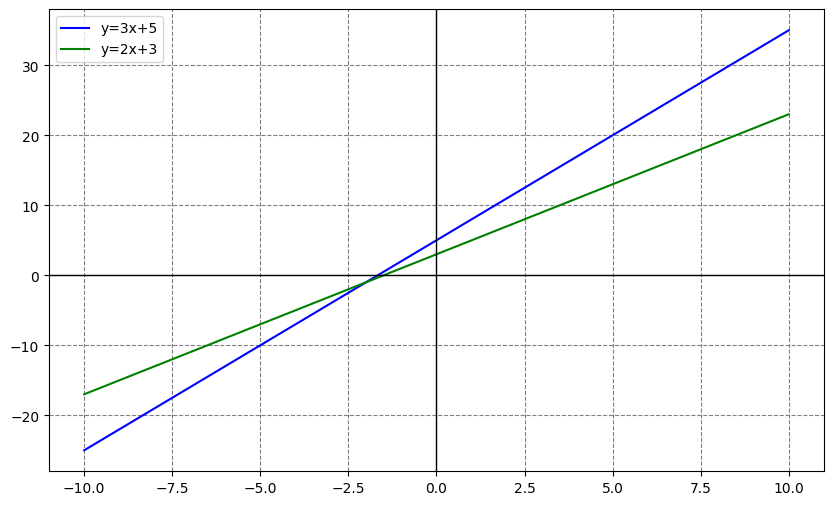

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 50)
y1 = 3*x+5
y2 = 2*x+3

plt.figure(figsize=(10,6))
plt.plot(x, y1, label='y=3x+5', color = 'b')
plt.plot(x, y2, label='y=2x+3',  color = 'g')
plt.axvline(0, color = 'black', linewidth = 1)
plt.axhline(0, color = 'black', linewidth = 1)
plt.legend()
plt.grid(linestyle = '--', color = 'gray')



In [ ]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [ ]:
np.arange(1,11,3)

array([ 1,  4,  7, 10])

In [ ]:
matrizx= np.array([[1,0],[4,1]])
inversa = np.linalg.inv(matrizx)
print(matrizx)
print(inversa)
identidad = matrizx *inversa
print(identidad)

[[1 0]
 [4 1]]
[[ 1.  0.]
 [-4.  1.]]
[[  1.   0.]
 [-16.   1.]]


In [ ]:
# Resolver sistemas de ecuaciones 3x+y = 1 y 2x+y = 1
import numpy as np
import matplotlib.pyplot as plt

# 3x+y = 1 y 2x+y = 1 donde 3x+y 2x+y = a y b = 1,1 nos faltaría sacar la x para el sistema de ecuaciones
# a =xb   x = a/b

a = np.array([[3,1],[2,1]])
b= np.array([[1],[1]])

# Resuelvo x = a/b

x = np.linalg.solve(a,b)
print(x)




[[0.]
 [1.]]


In [ ]:
# Calculemos la norma de un vector
vector = np.array([2,7])
norma = np.linalg.norm(vector)
print(norma)

7.280109889280518


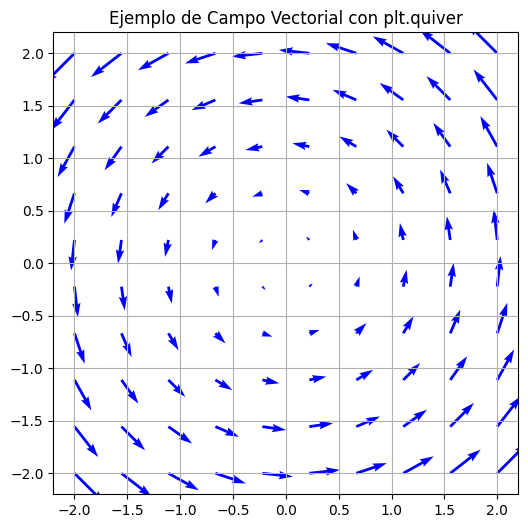

In [ ]:
# Uso de plt.quiver para graficar vectores
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la rejilla (X, Y)
x, y = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))

# 2. Definir las direcciones (U, V)
# Ejemplo: un campo circular
u = -y
v = x

# 3. Graficar
plt.figure(figsize=(6,6))
plt.quiver(x, y, u, v, color='blue')
plt.title("Ejemplo de Campo Vectorial con plt.quiver")
plt.grid(True)
plt.show()

In [ ]:
# Uso de widgets interactive, se puede usar en modelos de inteligencia artificial para ver que pasa si cambio los resultados.
import pandas as pd
import numpy as np
from ipywidgets import interact, widgets

# Tu dataset original
data = {
    'ID_Paciente': range(1, 11),
    'Edad': [45, np.nan, 30, 72, 25, 50, np.nan, 19, 34, 55],
    'Sexo': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', np.nan, 'F'],
    'Glucosa_Basal': [90, 110, 85, np.nan, 95, 105, 100, 92, 103, np.nan],
    'Biomarcador_Experimental': [1.2, np.nan, np.nan, 0.8, np.nan, 1.5, np.nan, np.nan, 1.1, np.nan],
    'Estado_Egreso': ['Vivo', 'Fallecido', 'Vivo', 'Fallecido', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Fallecido']
}
df = pd.DataFrame(data)

# 1. Definimos la función que filtrará los datos
def explorar_pacientes(sexo_filtro, min_edad, max_edad):
    df_filtrado = df.copy()

    # Filtrar por sexo (manejando el caso 'Todos')
    if sexo_filtro != 'Todos':
        df_filtrado = df_filtrado[df_filtrado['Sexo'] == sexo_filtro]

    # Filtrar por rango de edad (ignoramos temporalmente los NaN para el filtro numérico)
    # Si quieres mantener los NaN en el resultado, requeriría una lógica extra
    df_filtrado = df_filtrado[
        (df_filtrado['Edad'].isna()) |
        ((df_filtrado['Edad'] >= min_edad) & (df_filtrado['Edad'] <= max_edad))
    ]

    print(f"--- Pacientes encontrados: {len(df_filtrado)} ---")
    print(f"Promedio Glucosa Basal: {df_filtrado['Glucosa_Basal'].mean():.2f}")
    print(f"Porcentaje de faltantes en Biomarcador: {df_filtrado['Biomarcador_Experimental'].isna().mean() * 100:.1f}%")
    print("\n", df_filtrado)

# 2. Creamos los widgets interactivos y los conectamos a la función
interact(
    explorar_pacientes,
    sexo_filtro=widgets.Dropdown(options=['Todos', 'M', 'F'], value='Todos', description='Sexo:'),
    min_edad=widgets.IntSlider(min=15, max=80, step=1, value=15, description='Edad Mín:'),
    max_edad=widgets.IntSlider(min=15, max=80, step=1, value=80, description='Edad Máx:')
);

interactive(children=(Dropdown(description='Sexo:', options=('Todos', 'M', 'F'), value='Todos'), IntSlider(val…

In [ ]:
import pandas as pd
import numpy as np
from ipywidgets import interact, widgets

# 1. Recreamos tu dataset original con los datos faltantes
data = {
    'ID_Paciente': range(1, 11),
    'Edad': [45, np.nan, 30, 72, 25, 50, np.nan, 19, 34, 55],
    'Sexo': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', np.nan, 'F'],
    'Glucosa_Basal': [90, 110, 85, np.nan, 95, 105, 100, 92, 103, np.nan],
    'Biomarcador_Experimental': [1.2, np.nan, np.nan, 0.8, np.nan, 1.5, np.nan, np.nan, 1.1, np.nan],
    'Estado_Egreso': ['Vivo', 'Fallecido', 'Vivo', 'Fallecido', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Vivo', 'Fallecido']
}
df = pd.DataFrame(data)

# 2. Función que se ejecutará cada vez que muevas el widget
def probar_imputacion(metodo):
    df_imputado = df.copy()

    # Columnas numéricas a las que les aplicaremos la imputación
    columnas_numericas = ['Edad', 'Glucosa_Basal']

    for col in columnas_numericas:
        if metodo == 'Media':
            valor_imputacion = df[col].mean()
        elif metodo == 'Mediana':
            valor_imputacion = df[col].median()
        elif metodo == 'Moda':
            valor_imputacion = df[col].mode()[0] # Tomamos la primera moda si hay empate
        elif metodo == 'Valor Fijo (Cero)':
            valor_imputacion = 0

        # Aplicamos el reemplazo
        df_imputado[col] = df_imputado[col].fillna(valor_imputacion)

    # Mostramos los resultados en la consola de Jupyter
    print(f"=== Método Seleccionado: {metodo} ===")
    print(f"-> Edad imputada con: {df['Edad'].mean() if metodo=='Media' else df['Edad'].median() if metodo=='Mediana' else df['Edad'].mode()[0] if metodo=='Moda' else 0:.1f}")
    print(f"-> Glucosa imputada con: {df['Glucosa_Basal'].mean() if metodo=='Media' else df['Glucosa_Basal'].median() if metodo=='Mediana' else df['Glucosa_Basal'].mode()[0] if metodo=='Moda' else 0:.1f}\n")

    # Resumen estadístico rápido para notar los cambios en la desviación estándar (std) y la media
    print("--- Resumen Estadístico resultante ---")
    print(df_imputado[columnas_numericas].describe().loc[['mean', 'std', '50%']])

    print("\n--- Vista de los primeros 5 pacientes (Nota las filas 1 y 3) ---")
    # Mostramos las columnas clave para ver el cambio directo
    print(df_imputado[['ID_Paciente', 'Edad', 'Glucosa_Basal', 'Estado_Egreso']].head(5))

# 3. Construcción del widget interactivo
interact(
    probar_imputacion,
    metodo=widgets.ToggleButtons(
        options=['Media', 'Mediana', 'Moda', 'Valor Fijo (Cero)'],
        description='Imputación:',
        button_style='info' # Le da un color azul amigable a los botones
    )
);

interactive(children=(ToggleButtons(button_style='info', description='Imputación:', options=('Media', 'Mediana…